#1 EDA

In [ ]:
#Cell 0 - dataset loading
import pandas as pd

df = pd.read_csv('Training_data_8.csv')

print(df.shape)
df.head()

(93151, 2)


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Norte...,Business
1,<html> <body> News Headlines:\n <br> <b> APEC ...,Business
2,<html> <body> News Headlines:\n <br> <b> Recor...,Business
3,<html> <body> News Headlines:\n <br> <b> Rain ...,Sports
4,<html> <body> News Headlines:\n <br> <b> Consu...,Business


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#cell 1: mount google drive
print("Google Drive mount is not required when the CSV files are uploaded to the Colab session.")

Google Drive mount is not required when the CSV files are uploaded to the Colab session.


In [ ]:
import os
import re
import html
import string
import warnings
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from IPython.display import display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

text_column = 'News Headline'
label_column = 'News Topic'

print('EDA will use dataframe df with shape:', df.shape)
print('Text column:', text_column)
print('Label column:', label_column)


EDA will use dataframe df with shape: (93151, 2)
Text column: News Headline
Label column: News Topic


In [ ]:
# 1. Dataset Snapshot and Basic Integrity Checks
# ============================================================

basic_eda_rows = [
    ['Training samples', len(df)],
    ['Number of columns', df.shape[1]],
    ['Text column', text_column],
    ['Label column', label_column],
    ['Missing text values', df[text_column].isna().sum()],
    ['Missing label values', df[label_column].isna().sum()],
    ['Exact duplicate rows', df.duplicated().sum()],
    ['Unique raw headlines', df[text_column].nunique()],
    ['Number of classes', df[label_column].nunique()]
]

basic_eda_table = pd.DataFrame(basic_eda_rows, columns=['EDA item', 'Value'])
display(basic_eda_table)

display(df.head())


,EDA item,Value
0,Training samples,93151
1,Number of columns,2
2,Text column,News Headline
3,Label column,News Topic
4,Missing text values,0
5,Missing label values,0
6,Exact duplicate rows,16378
7,Unique raw headlines,76773
8,Number of classes,4


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Netwo...,Business
1,"<html> <body> News Headlines:\n <br> <b> APEC Countries to Standardize Trade Pacts SANTIAGO, Chile (Reuters) - Paci...",Business
2,<html> <body> News Headlines:\n <br> <b> Record Deficit for a Crucial Trade Figure The United States hit a record de...,Business
3,"<html> <body> News Headlines:\n <br> <b> Rain Puts 10 Title Contenders Up Front (AP) AP - Right now, things are goin...",Sports
4,<html> <body> News Headlines:\n <br> <b> Consumers return in Sept.; spending up 0.6 Consumer spending climbed 0.6 in...,Business


In [ ]:
# 2. EDA Cleaning Functions
# This cleaning is only for analysis/visualization.
# ============================================================

def clean_text_for_eda(text):
    text = html.unescape(str(text))
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'News Headlines:', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'#39;s', "'s", text)
    text = re.sub(r'#39;?', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def normalize_for_duplicate_check(text):
    text = clean_text_for_eda(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def count_sentences(text):
    pieces = re.split(r'[.!?]+', str(text))
    pieces = [piece.strip() for piece in pieces if piece.strip()]
    return len(pieces)

eda_df = df.copy()
eda_df['raw_text'] = eda_df[text_column].astype(str)
eda_df['clean_text'] = eda_df['raw_text'].apply(clean_text_for_eda)
eda_df['normalized_text'] = eda_df['raw_text'].apply(normalize_for_duplicate_check)

eda_df['raw_char_count'] = eda_df['raw_text'].str.len()
eda_df['raw_word_count'] = eda_df['raw_text'].apply(lambda x: len(str(x).split()))
eda_df['clean_char_count'] = eda_df['clean_text'].str.len()
eda_df['clean_word_count'] = eda_df['clean_text'].apply(lambda x: len(str(x).split()))
eda_df['sentence_count'] = eda_df['clean_text'].apply(count_sentences)

display(eda_df[[text_column, 'clean_text', label_column]].head())

,News Headline,clean_text,News Topic
0,<html> <body> News Headlines:\n <br> <b> Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Netwo...,"Nortel Networks Names Clent Richardson Chief Marketing Officer Nortel Networks Corp., North America 's bigger maker ...",Business
1,"<html> <body> News Headlines:\n <br> <b> APEC Countries to Standardize Trade Pacts SANTIAGO, Chile (Reuters) - Paci...","APEC Countries to Standardize Trade Pacts SANTIAGO, Chile (Reuters) - Pacific Rim nations have agreed to set minimum...",Business
2,<html> <body> News Headlines:\n <br> <b> Record Deficit for a Crucial Trade Figure The United States hit a record de...,Record Deficit for a Crucial Trade Figure The United States hit a record deficit of \$166.2 billion last quarter in ...,Business
3,"<html> <body> News Headlines:\n <br> <b> Rain Puts 10 Title Contenders Up Front (AP) AP - Right now, things are goin...","Rain Puts 10 Title Contenders Up Front (AP) AP - Right now, things are going Jeff Gordon's way #151; and that should...",Sports
4,<html> <body> News Headlines:\n <br> <b> Consumers return in Sept.; spending up 0.6 Consumer spending climbed 0.6 in...,"Consumers return in Sept.; spending up 0.6 Consumer spending climbed 0.6 in September, in line with expectations, as...",Business


In [ ]:
# 3. Main EDA Findings Table
# This table can be directly adapted for your report.
# ============================================================

label_per_normalized_text = eda_df.groupby('normalized_text')[label_column].nunique()
normalized_group_sizes = eda_df.groupby('normalized_text').size()
conflicting_duplicate_groups = int((label_per_normalized_text > 1).sum())

def percentage(mask):
    return round(mask.mean() * 100, 2)

html_mask = eda_df['raw_text'].str.contains(r'<[^>]+>', regex=True, na=False)
url_mask = eda_df['raw_text'].str.contains(r'http\S+|www\S+', regex=True, case=False, na=False)
digit_mask = eda_df['raw_text'].str.contains(r'\d', regex=True, na=False)
special_mask = eda_df['raw_text'].str.contains(r'[^A-Za-z0-9\s]', regex=True, na=False)
entity_mask = eda_df['raw_text'].str.contains(
    r'&[a-z]+;|#39;|\blt\b|\bgt\b|\bquot\b',
    regex=True,
    case=False,
    na=False
)
source_mask = eda_df['clean_text'].str.contains(
    r'\b(AP|Reuters|AFP)\b',
    regex=True,
    case=False,
    na=False
)

vocab_tokens = re.findall(r'[A-Za-z0-9]+', ' '.join(eda_df['clean_text'].str.lower()))
vocab_counter = Counter(vocab_tokens)
rare_word_count = sum(1 for word, count in vocab_counter.items() if count == 1)

main_eda_rows = [
    ['Training samples', f'{len(eda_df):,}'],
    ['Number of classes', eda_df[label_column].nunique()],
    ['Missing values in training data', int(eda_df[[text_column, label_column]].isna().sum().sum())],
    ['Exact duplicate rows', f'{int(eda_df.duplicated().sum()):,}'],
    ['Normalized duplicate headline groups', f'{int((normalized_group_sizes > 1).sum()):,}'],
    ['Conflicting duplicate headline groups', f'{conflicting_duplicate_groups:,}'],
    ['Average raw character count', round(eda_df['raw_char_count'].mean(), 2)],
    ['Average raw word count', round(eda_df['raw_word_count'].mean(), 2)],
    ['Average cleaned word count', round(eda_df['clean_word_count'].mean(), 2)],
    ['Average sentence count', round(eda_df['sentence_count'].mean(), 2)],
    ['Texts containing HTML tags', f'{percentage(html_mask)}%'],
    ['Texts containing URLs', f'{percentage(url_mask)}%'],
    ['Texts containing digits', f'{percentage(digit_mask)}%'],
    ['Texts containing special characters', f'{percentage(special_mask)}%'],
    ['Texts containing entity/source artifacts', f'{percentage(entity_mask)}%'],
    ['Texts containing AP/Reuters/AFP source tokens', f'{percentage(source_mask)}%'],
    ['Unique tokens after EDA cleaning', f'{len(vocab_counter):,}'],
    ['Rare tokens appearing once', f'{rare_word_count:,}']
]

main_eda_table = pd.DataFrame(main_eda_rows, columns=['EDA item', 'Value'])
display(main_eda_table)

,EDA item,Value
0,Training samples,"93,151"
1,Number of classes,4
2,Missing values in training data,0
3,Exact duplicate rows,"16,378"
4,Normalized duplicate headline groups,"10,635"
5,Conflicting duplicate headline groups,20
6,Average raw character count,295.71
7,Average raw word count,46.77
8,Average cleaned word count,37.66
9,Average sentence count,1.88


,Count,Percentage
News Topic,,
Business,36316,38.99%
Science and Technology,22422,24.07%
World News,19118,20.52%
Sports,15295,16.42%


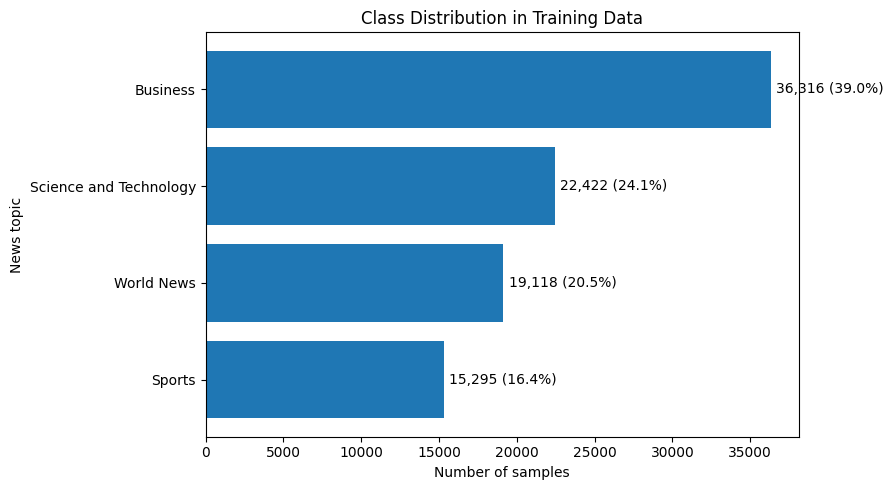

In [ ]:
# 4. Class Distribution
# ============================================================

class_counts = eda_df[label_column].value_counts()
class_percentages = (class_counts / len(eda_df) * 100).round(2)

class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages.astype(str) + '%'
})

display(class_distribution)

plt.figure(figsize=(9, 5))
bars = plt.barh(class_counts.index[::-1], class_counts.values[::-1])
plt.title('Class Distribution in Training Data')
plt.xlabel('Number of samples')
plt.ylabel('News topic')

for bar in bars:
    width = bar.get_width()
    pct = width / len(eda_df) * 100
    plt.text(
        width + max(class_counts.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,} ({pct:.1f}%)',
        va='center'
    )

plt.tight_layout()
plt.show()

,raw_words_mean,clean_words_mean,clean_words_median,clean_words_max,clean_chars_mean
News Topic,,,,,
World News,47.84,38.80,39.0,145,239.90
Sports,46.76,37.68,37.0,124,222.06
Business,46.54,37.39,37.0,134,231.35
Science and Technology,46.23,37.09,36.0,157,232.15


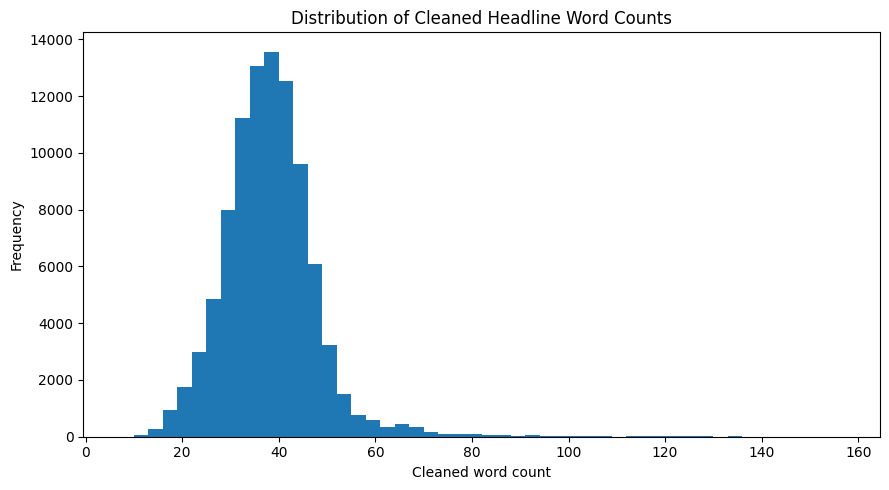

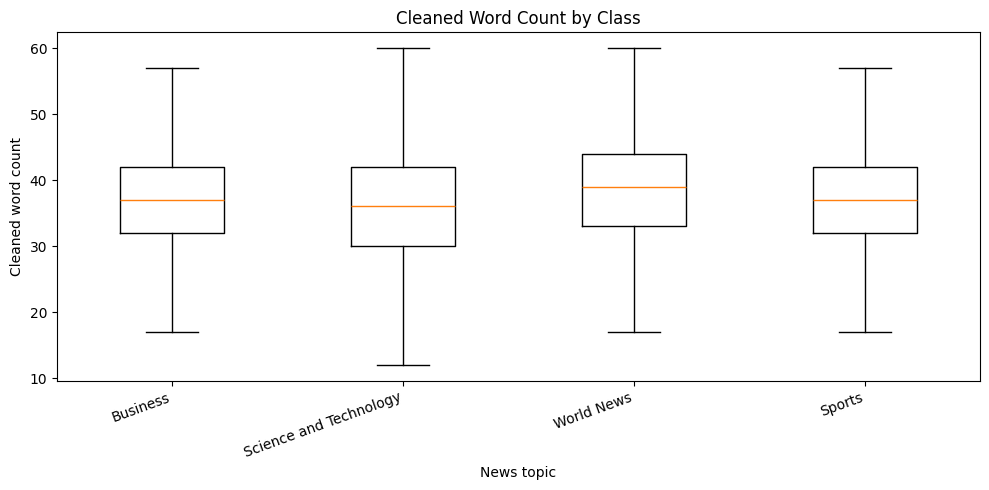

In [ ]:
# 5. Headline Length Analysis
# ============================================================

length_summary = eda_df.groupby(label_column).agg(
    raw_words_mean=('raw_word_count', 'mean'),
    clean_words_mean=('clean_word_count', 'mean'),
    clean_words_median=('clean_word_count', 'median'),
    clean_words_max=('clean_word_count', 'max'),
    clean_chars_mean=('clean_char_count', 'mean')
).round(2).sort_values('clean_words_mean', ascending=False)

display(length_summary)

plt.figure(figsize=(9, 5))
plt.hist(eda_df['clean_word_count'], bins=50)
plt.title('Distribution of Cleaned Headline Word Counts')
plt.xlabel('Cleaned word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

ordered_classes = class_counts.index.tolist()
boxplot_data = [
    eda_df.loc[eda_df[label_column] == topic, 'clean_word_count']
    for topic in ordered_classes
]

plt.figure(figsize=(10, 5))
plt.boxplot(boxplot_data, labels=ordered_classes, showfliers=False)
plt.title('Cleaned Word Count by Class')
plt.xlabel('News topic')
plt.ylabel('Cleaned word count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

,Pattern,Count,Percentage
0,HTML tags,93151,100.00
1,URLs,2003,2.15
2,Digits,54314,58.31
3,Special characters,93151,100.00
4,Entity/source artifacts,28487,30.58
5,AP/Reuters/AFP source tokens,18564,19.93


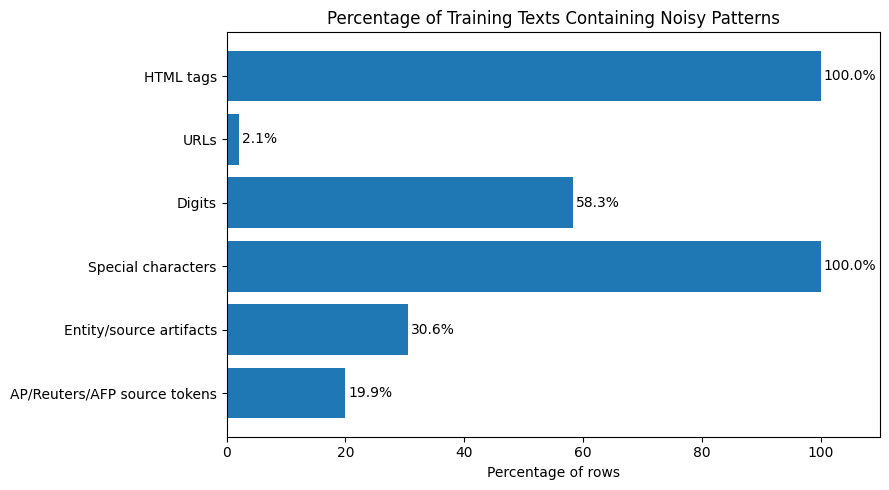

In [ ]:
# 6. Noise Pattern Analysis
# ============================================================

noise_patterns = pd.DataFrame({
    'Pattern': [
        'HTML tags',
        'URLs',
        'Digits',
        'Special characters',
        'Entity/source artifacts',
        'AP/Reuters/AFP source tokens'
    ],
    'Count': [
        int(html_mask.sum()),
        int(url_mask.sum()),
        int(digit_mask.sum()),
        int(special_mask.sum()),
        int(entity_mask.sum()),
        int(source_mask.sum())
    ]
})

noise_patterns['Percentage'] = (noise_patterns['Count'] / len(eda_df) * 100).round(2)

display(noise_patterns)

plt.figure(figsize=(9, 5))
bars = plt.barh(noise_patterns['Pattern'][::-1], noise_patterns['Percentage'][::-1])
plt.title('Percentage of Training Texts Containing Noisy Patterns')
plt.xlabel('Percentage of rows')

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center'
    )

plt.xlim(0, min(110, max(noise_patterns['Percentage']) + 15))
plt.tight_layout()
plt.show()

In [ ]:
# 7. Duplicate and Conflicting Headline Analysis
# ============================================================

repeated_headlines = (
    eda_df.groupby('normalized_text')
    .agg(
        row_count=(text_column, 'size'),
        label_count=(label_column, 'nunique')
    )
    .sort_values(['row_count', 'label_count'], ascending=False)
    .reset_index()
)

display(repeated_headlines.head(10))

conflict_keys = label_per_normalized_text[label_per_normalized_text > 1].index.tolist()

print('Conflicting normalized duplicate groups:', len(conflict_keys))

if len(conflict_keys) > 0:
    conflict_examples = eda_df[eda_df['normalized_text'].isin(conflict_keys)][
        ['normalized_text', text_column, label_column]
    ].sort_values('normalized_text').head(12)

    display(conflict_examples)
else:
    print('No conflicting duplicate groups found after normalization.')

,normalized_text,row_count,label_count
0,wal mart same store sales up 2 8 wal mart stores said saturday that shopping traffic dropped in the past week as it ...,8,1
1,acquitted tap executive to lead company tap pharmaceutical products inc s new president starts today about a month a...,7,1
2,aging population to slow down australian economy report a sharp increase in the number of aged people in the coming ...,7,1
3,american airlines gets credit line boost amr corp the owner of american airlines said friday that it received a 850 ...,7,1
4,brazil recognizes china as market economy hu afp afp brazil has recognized china as a market economy president hu ji...,7,1
5,daily forex commentary australia s commodity exports are expected to soar to a record 96 billion australian dollars ...,7,1
6,goldman settles suit involving ipo offer to bill ford goldman sachs group inc agreed wednesday to pay 13 4 million t...,7,1
7,lenovo confirms acquisition talks china s largest personal computer maker lenovo group ltd said on tuesday it was in...,7,1
8,nz friends to push for free trade with us new zealand s quot friends quot in washington will soon make another push ...,7,1
9,oil flat after drop more losses seen singapore reuters oil prices held steady on tuesday after falling 2 percent a d...,7,1


Conflicting normalized duplicate groups: 20


,normalized_text,News Headline,News Topic
75103,amazon to purchase chinese on line retailer amazon com inc has agreed to buy joyo com china s largest on line retail...,<html> <body> News Headlines:\n <br> <b> Amazon to purchase Chinese on-line retailer Amazon.com Inc. has agreed to b...,Business
24708,amazon to purchase chinese on line retailer amazon com inc has agreed to buy joyo com china s largest on line retail...,<html> <body> News Headlines:\n <br> <b> Amazon to purchase Chinese on-line retailer Amazon.com Inc. has agreed to b...,Science and Technology
21552,amazon to purchase chinese on line retailer amazon com inc has agreed to buy joyo com china s largest on line retail...,<html> <body> News Headlines:\n <br> <b> Amazon to purchase Chinese on-line retailer Amazon.com Inc. has agreed to b...,Business
50527,amd introduces low cost net access device in india reuters reuters u s chip maker advanced micro devices inc has int...,<html> <body> News Headlines:\n <br> <b> AMD introduces low-cost Net access device in India (Reuters) Reuters - U.S....,World News
86618,amd introduces low cost net access device in india reuters reuters u s chip maker advanced micro devices inc has int...,<html> <body> News Headlines:\n <br> <b> AMD Introduces Low-Cost Net Access Device in India (Reuters) Reuters - U.S....,Science and Technology
85800,at t posts 7 1 billion loss on writedown washington reuters at t corp on thursday reported a 7 1 billion third quart...,<html> <body> News Headlines:\n <br> <b> AT T Posts \$7.1 Billion Loss on Writedown &lt;p&gt;\&lt;/p&gt;&lt;p&gt; WA...,Science and Technology
82036,at t posts 7 1 billion loss on writedown washington reuters at t corp on thursday reported a 7 1 billion third quart...,<html> <body> News Headlines:\n <br> <b> AT T Posts \$7.1 Billion Loss on Writedown WASHINGTON (Reuters) - AT T Cor...,Business
93060,europe probe arrives at the moon the smart 1 lunar probe has entered into orbit around the moon the first ever europ...,<html> <body> News Headlines:\n <br> <b> Europe probe arrives at the Moon The Smart 1 lunar probe has entered into o...,World News
75952,europe probe arrives at the moon the smart 1 lunar probe has entered into orbit around the moon the first ever europ...,<html> <body> News Headlines:\n <br> <b> Europe probe arrives at the Moon The Smart 1 lunar probe has entered into o...,Science and Technology
84308,general dynamics posts profit defense contractor general dynamics corp reported a 23 percent jump in profit in its t...,<html> <body> News Headlines:\n <br> <b> General Dynamics Posts Profit Defense contractor General Dynamics Corp. rep...,Science and Technology


,Token,Frequency
0,new,17957
1,said,17380
2,reuters,14846
3,us,11945
4,ap,10345
5,oil,8304
6,year,8075
7,company,7596
8,world,6570
9,tuesday,6241


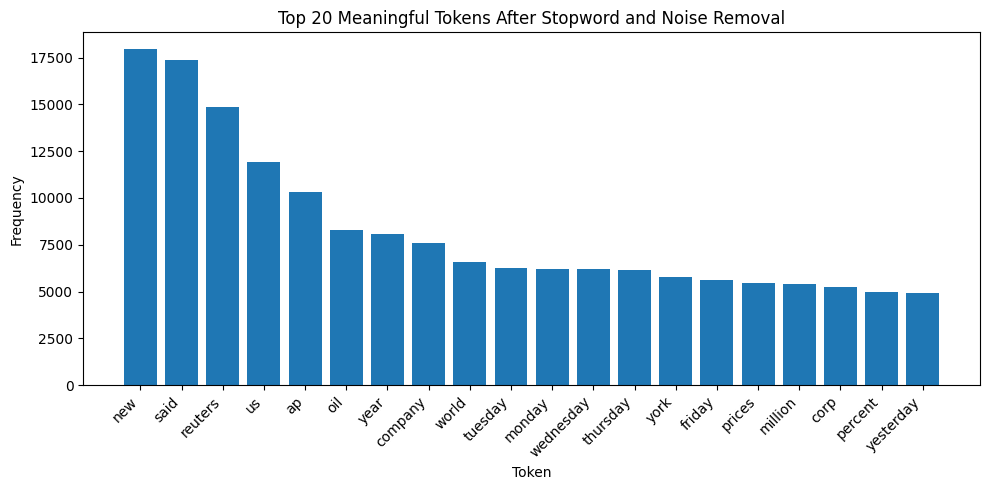

In [ ]:
# 8. Vocabulary and Most Frequent Meaningful Terms
# ============================================================

important_short_words = {'us', 'uk', 'eu', 'un', 'ai', 'tv', 'pc'}
eda_stop_words = set(ENGLISH_STOP_WORDS).difference(important_short_words)

noise_words = {
    'html', 'body', 'br', 'b', 'lt', 'gt', 'http', 'https', 'www',
    'quot', 'quote', 'amp', 'nbsp', 'href', 'news', 'headlines',
    'profile', 'research'
}

def tokenize_for_eda(text):
    return re.findall(r'[a-z0-9]+', str(text).lower())

all_tokens = []
filtered_tokens = []

for text in eda_df['clean_text']:
    tokens = tokenize_for_eda(text)
    all_tokens.extend(tokens)

    filtered_tokens.extend([
        token for token in tokens
        if token not in eda_stop_words
        and token not in noise_words
        and len(token) > 1
    ])

raw_frequency = Counter(all_tokens).most_common(20)
filtered_frequency = Counter(filtered_tokens).most_common(20)

frequency_table = pd.DataFrame(filtered_frequency, columns=['Token', 'Frequency'])
display(frequency_table)

plt.figure(figsize=(10, 5))
plt.bar(frequency_table['Token'], frequency_table['Frequency'])
plt.title('Top 20 Meaningful Tokens After Stopword and Noise Removal')
plt.xlabel('Token')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

,Class,Token,Frequency
0,Business,said,8919
1,Business,reuters,8233
2,Business,new,8192
3,Business,oil,7499
4,Business,us,7376
5,Business,company,5160
6,Business,prices,4985
7,Business,percent,4231
8,Business,york,4139
9,Business,year,4096


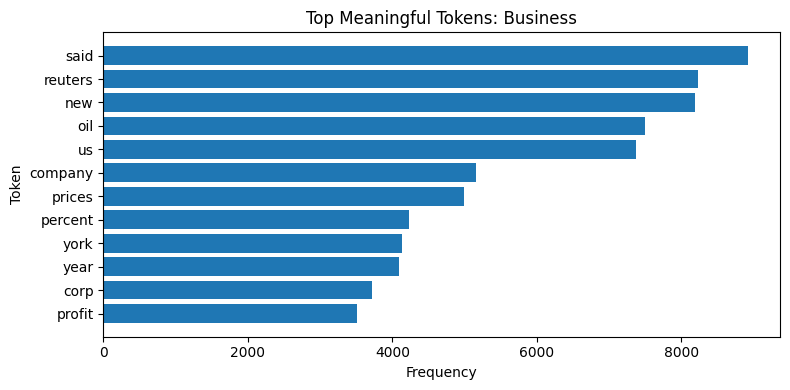

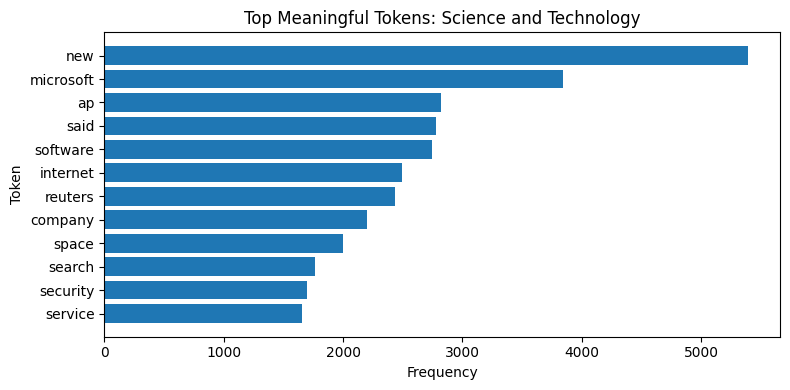

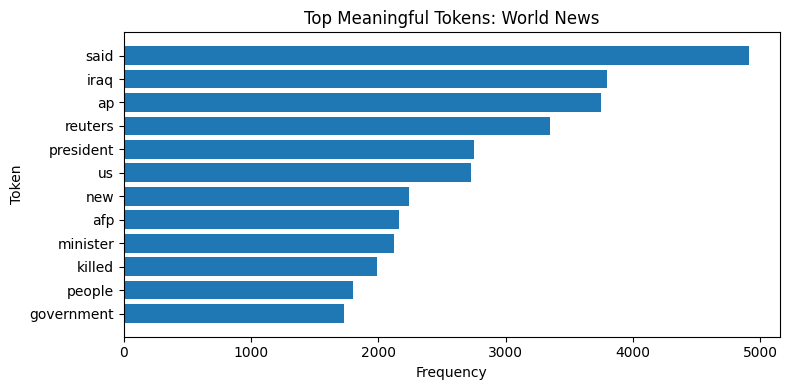

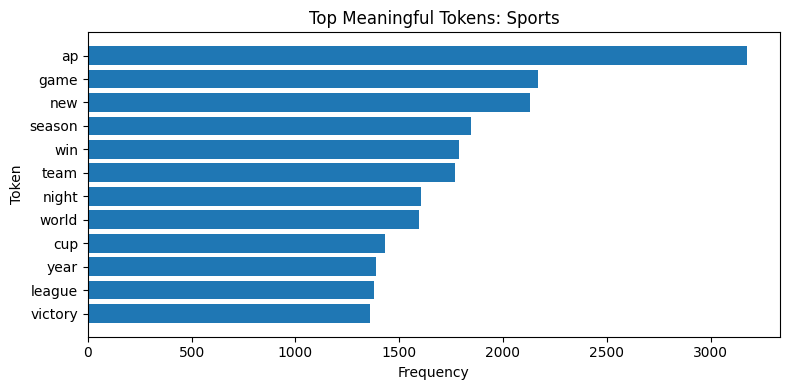

In [ ]:
# 9. Class-Specific Vocabulary Signals
# ============================================================

class_term_rows = []
class_top_terms = {}

for topic in class_counts.index:
    topic_tokens = []

    for text in eda_df.loc[eda_df[label_column] == topic, 'clean_text']:
        tokens = tokenize_for_eda(text)

        topic_tokens.extend([
            token for token in tokens
            if token not in eda_stop_words
            and token not in noise_words
            and len(token) > 1
        ])

    top_terms = Counter(topic_tokens).most_common(12)
    class_top_terms[topic] = top_terms

    for token, freq in top_terms:
        class_term_rows.append({
            'Class': topic,
            'Token': token,
            'Frequency': freq
        })

class_terms_table = pd.DataFrame(class_term_rows)
display(class_terms_table)

for topic, terms in class_top_terms.items():
    terms_df = pd.DataFrame(terms, columns=['Token', 'Frequency'])

    plt.figure(figsize=(8, 4))
    plt.barh(terms_df['Token'][::-1], terms_df['Frequency'][::-1])
    plt.title(f'Top Meaningful Tokens: {topic}')
    plt.xlabel('Frequency')
    plt.ylabel('Token')
    plt.tight_layout()
    plt.show()

Top bigrams


,Bigram,Frequency
0,new york,5762
1,ap ap,4850
2,reuters reuters,3454
3,oil prices,3156
4,york reuters,2411
5,united states,1983
6,prime minister,1573
7,said tuesday,1398
8,wall street,1387
9,said monday,1354


Top trigrams


,Trigram,Frequency
0,new york reuters,2411
1,securities exchange commission,424
2,york reuters stocks,421
3,reuters oil prices,347
4,delta air lines,302
5,canadian press canadian,286
6,press canadian press,286
7,crude oil prices,286
8,san francisco reuters,284
9,boston red sox,281


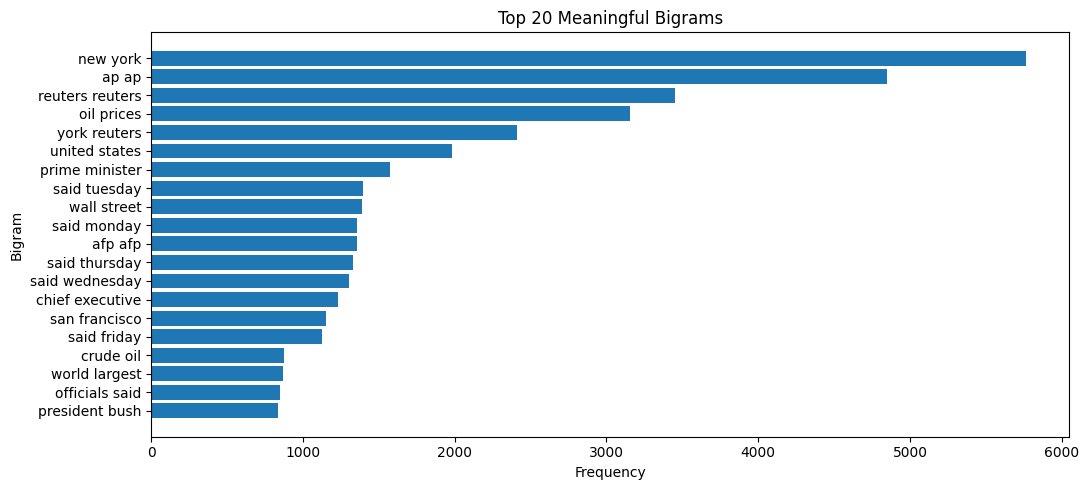

In [ ]:
# 10. Bigram and Trigram Analysis
# ============================================================

def build_ngrams(tokens, n):
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

bigram_counter = Counter(build_ngrams(filtered_tokens, 2))
trigram_counter = Counter(build_ngrams(filtered_tokens, 3))

top_bigrams = pd.DataFrame(
    bigram_counter.most_common(20),
    columns=['Bigram', 'Frequency']
)

top_trigrams = pd.DataFrame(
    trigram_counter.most_common(20),
    columns=['Trigram', 'Frequency']
)

print('Top bigrams')
display(top_bigrams)

print('Top trigrams')
display(top_trigrams)

plt.figure(figsize=(11, 5))
plt.barh(top_bigrams['Bigram'][::-1], top_bigrams['Frequency'][::-1])
plt.title('Top 20 Meaningful Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()


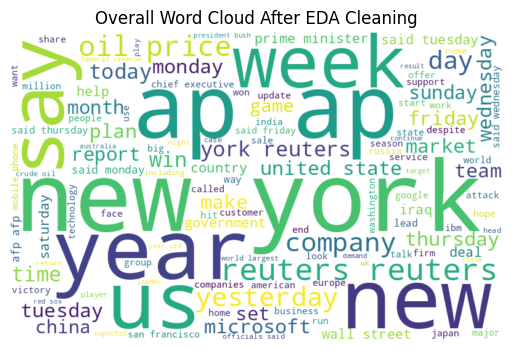

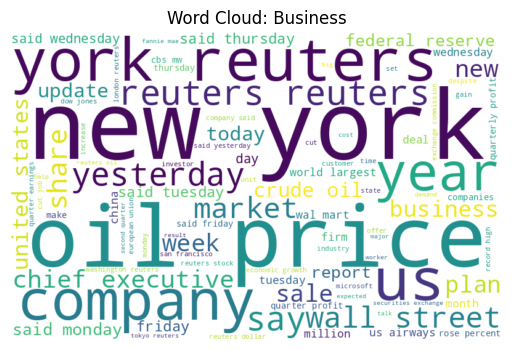

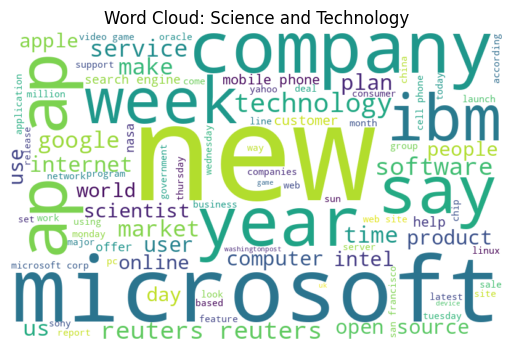

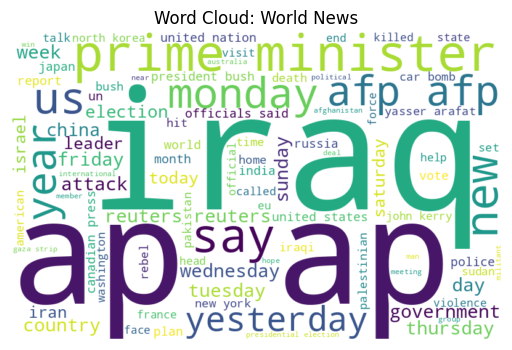

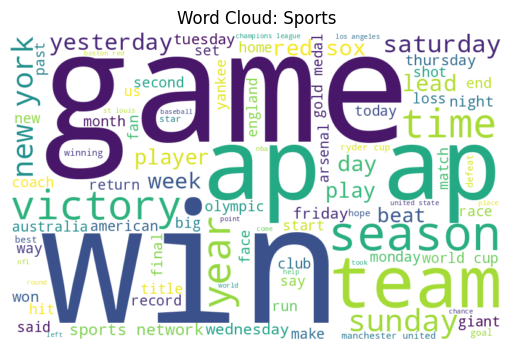

In [ ]:
# 11. Word Clouds
# ============================================================

try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

wordcloud_text = ' '.join(filtered_tokens)

plt.figure(figsize=(10, 4))
wc = WordCloud(
    width=800,
    height=500,
    background_color='white',
    max_words=120
).generate(wordcloud_text)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud After EDA Cleaning')
plt.show()

for topic in class_counts.index:
    topic_tokens = []

    for text in eda_df.loc[eda_df[label_column] == topic, 'clean_text']:
        tokens = tokenize_for_eda(text)

        topic_tokens.extend([
            token for token in tokens
            if token not in eda_stop_words
            and token not in noise_words
            and len(token) > 1
        ])

    plt.figure(figsize=(10, 4))
    wc = WordCloud(
        width=800,
        height=500,
        background_color='white',
        max_words=90
    ).generate(' '.join(topic_tokens))

    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud: {topic}')
    plt.show()



In [ ]:
# 12. EDA-Driven Preprocessing Decisions

# ============================================================

minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
imbalance_ratio = class_counts.max() / class_counts.min()

print('Key EDA findings and decisions')
print('1. The dataset has', f'{len(eda_df):,}', 'training rows and', eda_df[label_column].nunique(), 'classes.')
print('2. The largest class is', majority_class, 'and the smallest class is', minority_class, f'(imbalance ratio: {imbalance_ratio:.2f}:1).')
print('3. Because of this imbalance, macro F1-score should be emphasized along with accuracy.')
print('4. HTML/wrapper/entity/source artifacts are common, so optimum preprocessing should remove HTML tags, wrapper words, broken entities, URLs, and repeated source tokens.')
print('5. Normalized duplicates are present, so validation should avoid duplicate leakage where possible. A group-aware split is safer than a simple random split.')
print('6. Class-specific terms are visible in the top-token analysis, which supports using TF-IDF with unigram and bigram features.')
print('7. The length distributions show that classes are not separable by length alone, so the model should rely mainly on vocabulary and phrase patterns.')

preprocessing_decision_table = pd.DataFrame([
    [
        'No preprocessing',
        'Keep raw text unchanged'
    ],
    [
        'Extreme preprocessing',
        'Lowercase, remove HTML/URLs/digits/punctuation/stopwords/noise tokens, then apply stemming'
    ],
    [
        'Optimum preprocessing',
        'Remove HTML, URLs, entity fragments, wrapper words, source tokens, and extra symbols; preserve useful short tokens such as US, UK, EU, UN, and AI'
    ]
], columns=['Version', 'Main operations'])

display(preprocessing_decision_table)

Key EDA findings and decisions
1. The dataset has 93,151 training rows and 4 classes.
2. The largest class is Business and the smallest class is Sports (imbalance ratio: 2.37:1).
3. Because of this imbalance, macro F1-score should be emphasized along with accuracy.
4. HTML/wrapper/entity/source artifacts are common, so optimum preprocessing should remove HTML tags, wrapper words, broken entities, URLs, and repeated source tokens.
5. Normalized duplicates are present, so validation should avoid duplicate leakage where possible. A group-aware split is safer than a simple random split.
6. Class-specific terms are visible in the top-token analysis, which supports using TF-IDF with unigram and bigram features.
7. The length distributions show that classes are not separable by length alone, so the model should rely mainly on vocabulary and phrase patterns.


,Version,Main operations
0,No preprocessing,Keep raw text unchanged
1,Extreme preprocessing,"Lowercase, remove HTML/URLs/digits/punctuation/stopwords/noise tokens, then apply stemming"
2,Optimum preprocessing,"Remove HTML, URLs, entity fragments, wrapper words, source tokens, and extra symbols; preserve useful short tokens s..."


In [ ]:
# 20: Duplicate Analysis

duplicate_percentage = (df.duplicated().sum() / len(df)) * 100

print("Duplicate Percentage:", duplicate_percentage)

Duplicate Percentage: 17.58220523665876


# Pre Processing

In [ ]:
# 21 Required libraries for model building

!pip install gensim -q

import os
import re
import json
import html
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)

import nltk

try:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('omw-1.4')
    nltk.download('averaged_perceptron_tagger')
    nltk.download('averaged_perceptron_tagger_eng')
except:
    print("NLTK download was skipped. Existing resources or fallback options will be used.")

from IPython.display import display

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, RegexpParser

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec

print("Libraries imported successfully")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Libraries imported successfully


## Load Training and Testing Data

The project guideline says the dataset is already split into training and testing CSV files.  
So, the official testing file should be used only for final evaluation.

If the official testing CSV is not found in the folder, the notebook creates a temporary test split only so the full notebook can run. For final submission, upload the official testing CSV file.


In [ ]:
# 22 Load train and test data

train_file = "Training_data_8.csv"

possible_test_files = [
    "Testing_data_8.csv",
    "Test_data_8.csv",
    "testing_data_8.csv",
    "test_data_8.csv"
]

df = pd.read_csv(train_file)

test_file = None

for file_name in possible_test_files:
    if os.path.exists(file_name):
        test_file = file_name
        break

if test_file is not None:
    test_df = pd.read_csv(test_file)
    final_test_available = True
    print("Official testing file found:", test_file)
else:
    final_test_available = False
    print("Official testing file was not found.")
    print("Temporary test split is created only for running this notebook.")
    print("For final submission, upload the official Testing_data_8.csv file.")

print("Training data shape:", df.shape)
print("Columns:")
print(df.columns)

df.head()


Official testing file found: Test_data_8.csv
Training data shape: (93151, 2)
Columns:
Index(['News Headline', 'News Topic'], dtype='object')


,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Norte...,Business
1,<html> <body> News Headlines:\n <br> <b> APEC ...,Business
2,<html> <body> News Headlines:\n <br> <b> Recor...,Business
3,<html> <body> News Headlines:\n <br> <b> Rain ...,Sports
4,<html> <body> News Headlines:\n <br> <b> Consu...,Business


In [ ]:
# Select text and label columns
#23 split train/validation/test
text_column = "News Headline"
label_column = "News Topic"

if final_test_available == False:
    df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df[label_column]
    )

before_duplicate_rows = df.shape[0]
df = df.drop_duplicates(subset=[text_column, label_column]).reset_index(drop=True)
after_duplicate_rows = df.shape[0]

print("Duplicate training rows removed:", before_duplicate_rows - after_duplicate_rows)

df = df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[label_column]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTraining class distribution:")
print(train_df[label_column].value_counts())

print("\nValidation class distribution:")
print(val_df[label_column].value_counts())

print("\nTest class distribution:")
print(test_df[label_column].value_counts())


Duplicate training rows removed: 16378
Train shape: (61418, 2)
Validation shape: (15355, 2)
Test shape: (12000, 2)

Training class distribution:
News Topic
Science and Technology    17938
Business                  15950
World News                15294
Sports                    12236
Name: count, dtype: int64

Validation class distribution:
News Topic
Science and Technology    4484
Business                  3988
World News                3824
Sports                    3059
Name: count, dtype: int64

Test class distribution:
News Topic
Science and Technology    3000
World News                3000
Business                  3000
Sports                    3000
Name: count, dtype: int64


In [ ]:
# 24 Encode class labels

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df[label_column])
y_val = label_encoder.transform(val_df[label_column])
y_test = label_encoder.transform(test_df[label_column])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weight_values))

print("Classes:")
print(class_names)

print("Number of classes:", num_classes)

print("\nClass weights:")
print(class_weights)


Classes:
['Business', 'Science and Technology', 'Sports', 'World News']
Number of classes: 4

Class weights:
{0: np.float64(0.9626645768025078), 1: np.float64(0.8559761400379083), 2: np.float64(1.254862700228833), 3: np.float64(1.0039557996599975)}


## 5. Create Preprocessing Functions

Three versions are prepared according to the project guideline:

1. **No preprocessing**: original text exactly as it appears in the dataset.
2. **Extreme preprocessing**: heavy cleaning with dataset noise removal, lowercasing, punctuation/number removal, stopword removal, and stemming.
3. **Optimum preprocessing**: EDA-based keyword cleaning. The EDA showed repeated wrapper tokens and noisy tokens such as `lt`, `gt`, `http`, `quot`, `reuters`, `ap`, and `afp`. These are removed along with very short useless words and stopwords, but important short words such as `us`, `uk`, `eu`, `un`, and `ai` are kept. Lemmatization and stemming are not used in optimum preprocessing.

POS tagging and chunk parsing are checked separately for understanding the text pattern, but they are not used as preprocessing features for the final models.


In [ ]:
# 25 Create preprocessing functions

try:
    stop_words = set(stopwords.words("english"))
except:
    stop_words = set(ENGLISH_STOP_WORDS)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

custom_noise_words = set([
    "lt", "gt", "http", "https", "www", "quot", "quote",
    "reuters", "ap", "afp", "profile", "research"
])

dataset_noise_words = set([
    "html", "body", "br", "b", "amp", "nbsp", "href"
])

important_short_words = set([
    "us", "uk", "eu", "un", "ai", "tv", "pc"
])

stop_words = stop_words.difference(important_short_words)

optimum_noise_words = dataset_noise_words.union(custom_noise_words)
extreme_noise_words = dataset_noise_words.union(custom_noise_words)

def no_preprocessing(text):
    text = str(text)
    return text

def remove_dataset_noise(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'News Headlines:', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'#39;s', 's', text)
    text = re.sub(r'#39;?', ' ', text)
    return text

def basic_cleaning(text):
    text = remove_dataset_noise(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

def keep_useful_word(word):
    if word in important_short_words:
        return True
    elif len(word) > 2:
        return True
    else:
        return False

def extreme_preprocessing(text):
    text = basic_cleaning(text)

    words = text.split()
    clean_words = []

    for word in words:
        if word not in stop_words and word not in extreme_noise_words and keep_useful_word(word):
            clean_words.append(stemmer.stem(word))

    text = " ".join(clean_words)

    if text == "":
        text = "emptytext"

    return text

def optimum_preprocessing(text):
    text = basic_cleaning(text)

    words = text.split()
    clean_words = []

    for word in words:
        if word not in stop_words and word not in optimum_noise_words and keep_useful_word(word):
            clean_words.append(word)

    text = " ".join(clean_words)

    if text == "":
        text = "emptytext"

    return text

print("Preprocessing functions created")


Preprocessing functions created


## 6. Create Raw, Extreme, and Optimum Preprocessed Datasets

In [ ]:
# 26 Create three preprocessed datasets

preprocessing_functions = {
    "No preprocessing": no_preprocessing,
    "Extreme preprocessing": extreme_preprocessing,
    "Optimum preprocessing": optimum_preprocessing
}

preprocessed_data = {}

for preprocessing_name, preprocessing_function in preprocessing_functions.items():
    print("\nPreparing:", preprocessing_name)

    temp_train_df = train_df.copy()
    temp_val_df = val_df.copy()
    temp_test_df = test_df.copy()

    temp_train_df["processed_text"] = temp_train_df[text_column].apply(preprocessing_function)
    temp_val_df["processed_text"] = temp_val_df[text_column].apply(preprocessing_function)
    temp_test_df["processed_text"] = temp_test_df[text_column].apply(preprocessing_function)

    preprocessed_data[preprocessing_name] = {
        "train_text": temp_train_df["processed_text"].values,
        "val_text": temp_val_df["processed_text"].values,
        "test_text": temp_test_df["processed_text"].values,
        "train_df": temp_train_df,
        "val_df": temp_val_df,
        "test_df": temp_test_df
    }

    print("Done:", preprocessing_name)

print("\nAll three datasets are ready")



Preparing: No preprocessing
Done: No preprocessing

Preparing: Extreme preprocessing
Done: Extreme preprocessing

Preparing: Optimum preprocessing
Done: Optimum preprocessing

All three datasets are ready


In [ ]:
# 27 Show preprocessing examples

sample_rows = []

for preprocessing_name in preprocessed_data.keys():
    sample_rows.append({
        "Preprocessing": preprocessing_name,
        "Text": preprocessed_data[preprocessing_name]["train_text"][0]
    })

sample_df = pd.DataFrame(sample_rows)

display(sample_df)


,Preprocessing,Text
0,No preprocessing,<html> <body> News Headlines:\n <br> <b> Austr...
1,Extreme preprocessing,australia minist want iaea post australia fore...
2,Optimum preprocessing,australia minister want iaea post australia fo...


## Review of Optimum Preprocessing Based on EDA

From the EDA, the dataset has four classes, no missing values, and a noticeable number of duplicates. The raw text also contains repeated wrapper text and noisy tokens from the dataset formatting.

The most frequent words and bigrams showed tokens such as `lt`, `gt`, `http`, `quot`, `b`, `profile`, and `research`. These are not useful topic words. The class-wise frequent words also showed `reuters`, `ap`, and `afp` very often. These are source names, not actual topic meaning.

So the optimum preprocessing removes these EDA-detected noisy words, removes stopwords for better keyword focus, and removes very short useless words while keeping important short topic words such as `us`, `uk`, `eu`, `un`, and `ai`. Lemmatization and stemming are avoided in optimum preprocessing so the original news keywords stay readable and meaningful.


In [ ]:
# 28 Compare average word count after preprocessing

preprocessing_summary_rows = []

for preprocessing_name in preprocessed_data.keys():
    train_text = preprocessed_data[preprocessing_name]["train_text"]

    word_counts = []
    for text in train_text:
        word_counts.append(len(str(text).split()))

    preprocessing_summary_rows.append({
        "Preprocessing": preprocessing_name,
        "Average Word Count": np.mean(word_counts),
        "Minimum Word Count": np.min(word_counts),
        "Maximum Word Count": np.max(word_counts)
    })

preprocessing_word_count_df = pd.DataFrame(preprocessing_summary_rows)
display(preprocessing_word_count_df)


,Preprocessing,Average Word Count,Minimum Word Count,Maximum Word Count
0,No preprocessing,46.803136,17,166
1,Extreme preprocessing,24.363135,5,101
2,Optimum preprocessing,24.363135,5,101


## POS Tagging and Parsing Check

POS tagging and shallow parsing can help us understand sentence structure. However, we are not using POS tags with lemmatization, and we are not using POS/parsing output as final model features.

Reason: the project requires TF-IDF and Skip-gram word representations. POS/parsing is useful for analysis, but adding it to the final feature pipeline is not necessary for this project.

In [ ]:
# 29 POS tagging and shallow parsing example

sample_sentence = preprocessed_data["Optimum preprocessing"]["train_text"][0]
sample_tokens = str(sample_sentence).split()[:25]

pos_tags = pos_tag(sample_tokens)

print("Sample tokens:")
print(sample_tokens)

print("\nPOS tags:")
print(pos_tags)

chunk_grammar = "NP: {<JJ.*>*<NN.*>+}"
chunk_parser = RegexpParser(chunk_grammar)
chunk_tree = chunk_parser.parse(pos_tags)

print("\nShallow parsing output:")
print(chunk_tree)


Sample tokens:
['australia', 'minister', 'want', 'iaea', 'post', 'australia', 'foreign', 'minister', 'said', 'wednesday', 'united', 'states', 'asked', 'challenge', 'international', 'atomic', 'energy', 'agency', 'head', 'mohamed', 'elbaradei', 'top', 'job', 'nuclear', 'watchdog']

POS tags:
[('australia', 'NNS'), ('minister', 'NN'), ('want', 'VBP'), ('iaea', 'JJ'), ('post', 'NN'), ('australia', 'IN'), ('foreign', 'JJ'), ('minister', 'NN'), ('said', 'VBD'), ('wednesday', 'JJ'), ('united', 'JJ'), ('states', 'NNS'), ('asked', 'VBD'), ('challenge', 'JJ'), ('international', 'JJ'), ('atomic', 'JJ'), ('energy', 'NN'), ('agency', 'NN'), ('head', 'NN'), ('mohamed', 'VBD'), ('elbaradei', 'JJ'), ('top', 'JJ'), ('job', 'NN'), ('nuclear', 'JJ'), ('watchdog', 'NN')]

Shallow parsing output:
(S
  (NP australia/NNS minister/NN)
  want/VBP
  (NP iaea/JJ post/NN)
  australia/IN
  (NP foreign/JJ minister/NN)
  said/VBD
  (NP wednesday/JJ united/JJ states/NNS)
  asked/VBD
  (NP
    challenge/JJ
    interna

## Why No Preprocessing Can Show Similar Accuracy to Optimum Preprocessing

No preprocessing and optimum preprocessing can show similar accuracy because the useful topic words are present in both versions. Also, TF-IDF already removes much of the effect of punctuation and very common repeated words by assigning lower importance to words that appear in almost every document.

So, even though optimum preprocessing is cleaner, the raw text can still perform well because words like `oil`, `microsoft`, `iraq`, `game`, `team`, `minister`, and `software` are still visible to the model. The comparison result is still important because it proves whether cleaning actually helps for this assigned dataset.

# Evaluation Helper Function




In [ ]:
#30 Evaluation function

all_results = []
all_reports = {}
all_confusion_matrices = {}
tuning_rows = {}

def evaluate_model(preprocessing_name, representation_name, model_name, y_true, y_pred):
    global all_results

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(num_classes))
    )

    experiment_name = preprocessing_name + " | " + representation_name + " | " + model_name

    all_results = [
        row for row in all_results
        if not (
            row["Preprocessing"] == preprocessing_name
            and row["Representation"] == representation_name
            and row["Model"] == model_name
        )
    ]

    all_results.append({
        "Preprocessing": preprocessing_name,
        "Representation": representation_name,
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    all_reports[experiment_name] = report
    all_confusion_matrices[experiment_name] = cm

    print("\nExperiment:", experiment_name)
    print("Accuracy:", accuracy)
    print("Macro F1:", macro_f1)
    print("\nClassification Report:")
    print(report)

    return accuracy, macro_f1

print("Evaluation function is ready")


Evaluation function is ready


## Random Hyperparameter Selection Function

In [ ]:
# Random hyperparameter selection function

import random

def create_random_settings(search_space, number_of_trials, random_state=42):
    random.seed(random_state)

    settings_list = []

    for i in range(number_of_trials):
        setting = {}

        for key in search_space.keys():
            setting[key] = random.choice(search_space[key])

        settings_list.append(setting)

    return settings_list

tfidf_lr_search_space = {
    "max_features": [3000, 5000, 8000],
    "ngram_range": [(1, 1), (1, 2)],
    "C": [0.5, 1.0, 2.0]
}

tfidf_lr_settings = create_random_settings(
    tfidf_lr_search_space,
    number_of_trials=3,
    random_state=42
)

dnn_search_space = {
    "max_features": [3000, 5000, 8000],
    "first_layer_neurons": [128, 256, 512],
    "second_layer_neurons": [64, 128, 256],
    "third_layer_neurons": [32, 64, 128],
    "dropout_rate": [0.3, 0.4, 0.5],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [64, 128],
    "epochs": [10, 15]
}

dnn_settings = create_random_settings(
    dnn_search_space,
    number_of_trials=3,
    random_state=42
)

sequence_search_space = {
    "units": [64, 128],
    "dropout_rate": [0.3, 0.4, 0.5],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [64, 128],
    "epochs": [10, 15]
}

sequence_settings = create_random_settings(
    sequence_search_space,
    number_of_trials=3,
    random_state=42
)

print("TF-IDF Logistic Regression settings:")
display(pd.DataFrame(tfidf_lr_settings))

print("DNN settings:")
display(pd.DataFrame(dnn_settings))

print("Sequence model settings:")
display(pd.DataFrame(sequence_settings))

TF-IDF Logistic Regression settings:


,max_features,ngram_range,C
0,8000,"(1, 1)",0.5
1,8000,"(1, 2)",0.5
2,3000,"(1, 1)",2.0


DNN settings:


,max_features,first_layer_neurons,second_layer_neurons,third_layer_neurons,dropout_rate,learning_rate,batch_size,epochs
0,8000,128,64,128,0.4,0.001,64,10
1,8000,128,256,128,0.5,0.001,128,10
2,3000,128,64,32,0.5,0.001,64,15


Sequence model settings:


,units,dropout_rate,learning_rate,batch_size,epochs
0,64,0.3,0.0005,64,10
1,64,0.5,0.0010,64,15
2,64,0.3,0.0010,64,10


## Loss Curve Plotting Functions

In [ ]:
# Loss curve and accuracy curve functions

all_histories = {}

def plot_loss_curve(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_accuracy_curve(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def plot_training_curves(history, title):
    plot_loss_curve(history, title + " Loss Curve")
    plot_accuracy_curve(history, title + " Accuracy Curve")

def plot_all_training_curves(history_dictionary):
    for history_name, history in history_dictionary.items():
        plot_training_curves(history, history_name)

print("Loss curve functions are ready")

Loss curve functions are ready


#TF-IDF FOR logistic Regression and Deep NN model

## 7 and 8. TF-IDF Feature Extraction and One Machine Learning Model

Logistic Regression is used as the required machine learning model because it works well with TF-IDF for text classification and is easy to explain during viva.


In [ ]:
# 31 TF-IDF with Logistic Regression

tfidf_data = {}
ml_tuning_rows = []

tfidf_settings = tfidf_lr_settings

print("TF-IDF Logistic Regression settings:")
display(pd.DataFrame(tfidf_settings))

for preprocessing_name in preprocessed_data.keys():
    print("\n==============================")
    print("Preprocessing:", preprocessing_name)
    print("==============================")

    best_f1 = -1
    best_setting = None
    best_vectorizer = None
    best_model = None
    best_train_tfidf = None
    best_val_tfidf = None
    best_test_tfidf = None

    train_text = preprocessed_data[preprocessing_name]["train_text"]
    val_text = preprocessed_data[preprocessing_name]["val_text"]
    test_text = preprocessed_data[preprocessing_name]["test_text"]

    for setting in tfidf_settings:
        print("\nTrying setting:", setting)

        vectorizer = TfidfVectorizer(
            max_features=setting["max_features"],
            ngram_range=setting["ngram_range"]
        )

        X_train_tfidf = vectorizer.fit_transform(train_text)
        X_val_tfidf = vectorizer.transform(val_text)
        X_test_tfidf = vectorizer.transform(test_text)

        lr_model = LogisticRegression(
            max_iter=1000,
            C=setting["C"],
            class_weight="balanced"
        )

        lr_model.fit(X_train_tfidf, y_train)

        val_pred = lr_model.predict(X_val_tfidf)
        val_f1 = f1_score(y_val, val_pred, average="macro")

        ml_tuning_rows.append({
            "Preprocessing": preprocessing_name,
            "Model": "Logistic Regression",
            "max_features": setting["max_features"],
            "ngram_range": str(setting["ngram_range"]),
            "C": setting["C"],
            "Validation Macro F1": val_f1
        })

        print("Validation Macro F1:", val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_setting = setting
            best_vectorizer = vectorizer
            best_model = lr_model
            best_train_tfidf = X_train_tfidf
            best_val_tfidf = X_val_tfidf
            best_test_tfidf = X_test_tfidf

    print("\nBest TF-IDF setting:")
    print(best_setting)

    test_pred = best_model.predict(best_test_tfidf)

    evaluate_model(
        preprocessing_name,
        "TF-IDF",
        "Logistic Regression",
        y_test,
        test_pred
    )

    tfidf_data[preprocessing_name] = {
        "vectorizer": best_vectorizer,
        "X_train": best_train_tfidf,
        "X_val": best_val_tfidf,
        "X_test": best_test_tfidf,
        "best_setting": best_setting
    }

ml_tuning_df = pd.DataFrame(ml_tuning_rows)

print("\nML tuning log:")
display(ml_tuning_df)


TF-IDF Logistic Regression settings:


,max_features,ngram_range,C
0,8000,"(1, 1)",0.5
1,8000,"(1, 2)",0.5
2,3000,"(1, 1)",2.0



Preprocessing: No preprocessing

Trying setting: {'max_features': 8000, 'ngram_range': (1, 1), 'C': 0.5}
Validation Macro F1: 0.9080129580679285

Trying setting: {'max_features': 8000, 'ngram_range': (1, 2), 'C': 0.5}
Validation Macro F1: 0.904526634706244

Trying setting: {'max_features': 3000, 'ngram_range': (1, 1), 'C': 2.0}
Validation Macro F1: 0.8970160610124457

Best TF-IDF setting:
{'max_features': 8000, 'ngram_range': (1, 1), 'C': 0.5}

Experiment: No preprocessing | TF-IDF | Logistic Regression
Accuracy: 0.91225
Macro F1: 0.9120219280056434

Classification Report:
                        precision    recall  f1-score   support

              Business       0.88      0.88      0.88      3000
Science and Technology       0.90      0.90      0.90      3000
                Sports       0.94      0.98      0.96      3000
            World News       0.93      0.90      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91

,Preprocessing,Model,max_features,ngram_range,C,Validation Macro F1
0,No preprocessing,Logistic Regression,8000,"(1, 1)",0.5,0.908013
1,No preprocessing,Logistic Regression,8000,"(1, 2)",0.5,0.904527
2,No preprocessing,Logistic Regression,3000,"(1, 1)",2.0,0.897016
3,Extreme preprocessing,Logistic Regression,8000,"(1, 1)",0.5,0.900297
4,Extreme preprocessing,Logistic Regression,8000,"(1, 2)",0.5,0.902327
5,Extreme preprocessing,Logistic Regression,3000,"(1, 1)",2.0,0.891433
6,Optimum preprocessing,Logistic Regression,8000,"(1, 1)",0.5,0.903668
7,Optimum preprocessing,Logistic Regression,8000,"(1, 2)",0.5,0.902042
8,Optimum preprocessing,Logistic Regression,3000,"(1, 1)",2.0,0.887929


## 9. Deep Neural Network with TF-IDF

The DNN uses TF-IDF features. The first hidden layer has more than 128 neurons and the model has multiple dense layers, satisfying the project requirement.


In [ ]:
# 32 DNN model builder

def build_dnn_model(input_dim, first_layer_neurons, second_layer_neurons, third_layer_neurons, dropout_rate, learning_rate):
    model = Sequential()

    model.add(Dense(first_layer_neurons, activation="relu", input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))

    model.add(Dense(second_layer_neurons, activation="relu"))
    model.add(Dropout(dropout_rate))

    model.add(Dense(third_layer_neurons, activation="relu"))
    model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation="softmax"))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("DNN model builder is ready")

DNN model builder is ready


In [ ]:
# 33 Train Deep Neural Network models with TF-IDF

dnn_tuning_rows = []
dnn_histories = {}

dnn_settings = dnn_settings

print("DNN settings:")
display(pd.DataFrame(dnn_settings))

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

for preprocessing_name in preprocessed_data.keys():
    print("\n==============================")
    print("DNN Preprocessing:", preprocessing_name)
    print("==============================")

    train_text = preprocessed_data[preprocessing_name]["train_text"]
    val_text = preprocessed_data[preprocessing_name]["val_text"]
    test_text = preprocessed_data[preprocessing_name]["test_text"]

    best_f1 = -1
    best_setting = None
    best_model = None
    best_vectorizer = None
    best_history = None
    best_test_dense = None

    for setting in dnn_settings:
        print("\nTrying DNN setting:", setting)

        vectorizer = TfidfVectorizer(max_features=setting["max_features"])

        X_train_tfidf = vectorizer.fit_transform(train_text)
        X_val_tfidf = vectorizer.transform(val_text)
        X_test_tfidf = vectorizer.transform(test_text)

        X_train_dense = X_train_tfidf.toarray().astype("float32")
        X_val_dense = X_val_tfidf.toarray().astype("float32")
        X_test_dense = X_test_tfidf.toarray().astype("float32")

        tf.keras.backend.clear_session()

        dnn_model = build_dnn_model(
            input_dim=X_train_dense.shape[1],
            first_layer_neurons=setting["first_layer_neurons"],
            second_layer_neurons=setting["second_layer_neurons"],
            third_layer_neurons=setting["third_layer_neurons"],
            dropout_rate=setting["dropout_rate"],
            learning_rate=setting["learning_rate"]
        )

        dnn_model.summary()

        history = dnn_model.fit(
            X_train_dense,
            y_train,
            epochs=setting["epochs"],
            batch_size=setting["batch_size"],
            validation_data=(X_val_dense, y_val),
            callbacks=[early_stop],
            class_weight=class_weights,
            verbose=1
        )

        val_pred_prob = dnn_model.predict(X_val_dense)
        val_pred = np.argmax(val_pred_prob, axis=1)

        val_f1 = f1_score(y_val, val_pred, average="macro")

        dnn_tuning_rows.append({
            "Preprocessing": preprocessing_name,
            "Model": "DNN",
            "first_layer_neurons": setting["first_layer_neurons"],
            "second_layer_neurons": setting["second_layer_neurons"],
            "third_layer_neurons": setting["third_layer_neurons"],
            "dropout_rate": setting["dropout_rate"],
            "learning_rate": setting["learning_rate"],
            "batch_size": setting["batch_size"],
            "epochs": setting["epochs"],
            "Validation Macro F1": val_f1
        })

        print("Validation Macro F1:", val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_setting = setting
            best_model = dnn_model
            best_vectorizer = vectorizer
            best_history = history
            best_test_dense = X_test_dense

        del X_train_dense
        del X_val_dense

    print("\nBest DNN setting:")
    print(best_setting)

    test_pred_prob = best_model.predict(best_test_dense)
    test_pred = np.argmax(test_pred_prob, axis=1)

    evaluate_model(
        preprocessing_name,
        "TF-IDF",
        "Deep Neural Network",
        y_test,
        test_pred
    )

    dnn_histories[preprocessing_name] = best_history
    all_histories["DNN | " + preprocessing_name] = best_history

    del best_test_dense

dnn_tuning_df = pd.DataFrame(dnn_tuning_rows)

print("\nDNN tuning log:")
display(dnn_tuning_df)


DNN settings:


,max_features,first_layer_neurons,second_layer_neurons,third_layer_neurons,dropout_rate,learning_rate,batch_size,epochs
0,8000,128,64,128,0.4,0.001,64,10
1,8000,128,256,128,0.5,0.001,128,10
2,3000,128,64,32,0.5,0.001,64,15



DNN Preprocessing: No preprocessing

Trying DNN setting: {'max_features': 8000, 'first_layer_neurons': 128, 'second_layer_neurons': 64, 'third_layer_neurons': 128, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 10}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

...

 Total params: 394,596 (1.51 MB)

 Trainable params: 394,596 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
960/960 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7802 - loss: 0.5988 - val_accuracy: 0.8852 - val_loss: 0.3496
Epoch 2/15
960/960 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8833 - loss: 0.3760 - val_accuracy: 0.8902 - val_loss: 0.3370
Epoch 3/15
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8968 - loss: 0.3277 - val_accuracy: 0.8873 - val_loss: 0.3475
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Validation Macro F1: 0.8886031590732203

Best DNN setting:
{'max_features': 8000, 'first_layer_neurons': 128, 'second_layer_neurons': 64, 'third_layer_neurons': 128, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 10}
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Experiment: Optimum preprocessing | TF-IDF | Deep Neural Network
Accuracy: 0.911
Macro F1: 0.9109060152028285

Classification Report:
                        precision    recall  f1-score   support

              Business       0.87      0.88      0.88      3000
Science and Technology    

,Preprocessing,Model,first_layer_neurons,second_layer_neurons,third_layer_neurons,dropout_rate,learning_rate,batch_size,epochs,Validation Macro F1
0,No preprocessing,DNN,128,64,128,0.4,0.001,64,10,0.913177
1,No preprocessing,DNN,128,256,128,0.5,0.001,128,10,0.912462
2,No preprocessing,DNN,128,64,32,0.5,0.001,64,15,0.900044
3,Extreme preprocessing,DNN,128,64,128,0.4,0.001,64,10,0.908175
4,Extreme preprocessing,DNN,128,256,128,0.5,0.001,128,10,0.906870
5,Extreme preprocessing,DNN,128,64,32,0.5,0.001,64,15,0.896462
6,Optimum preprocessing,DNN,128,64,128,0.4,0.001,64,10,0.907309
7,Optimum preprocessing,DNN,128,256,128,0.5,0.001,128,10,0.905734
8,Optimum preprocessing,DNN,128,64,32,0.5,0.001,64,15,0.888603


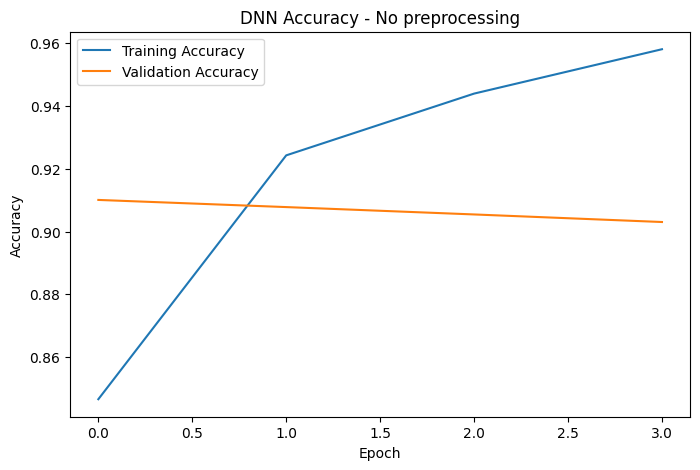

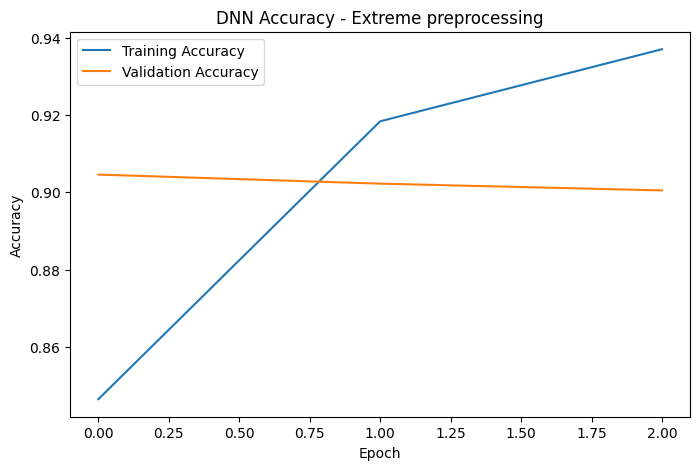

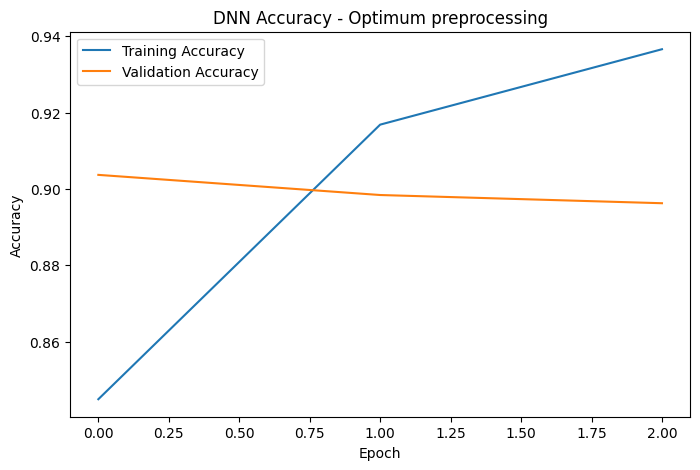

In [ ]:
# 34 Plot DNN training history

for preprocessing_name, history in dnn_histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("DNN Accuracy - " + preprocessing_name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


#Skipgram for 6 NN models

## 10 and 11. Skip-gram Word2Vec and Padded Sequences

Skip-gram Word2Vec is trained using `sg=1`.  
The Word2Vec vectors are then used to create the embedding matrix for the recurrent neural network models.


In [ ]:
# 35 Train Skip-gram Word2Vec and prepare padded sequences

num_words = 10000
max_len = 60
embedding_dim = 100
word2vec_epochs = 15

sequence_data = {}

for preprocessing_name in preprocessed_data.keys():
    print("\n==============================")
    print("Preparing Skip-gram data for:", preprocessing_name)
    print("==============================")

    train_text = preprocessed_data[preprocessing_name]["train_text"]
    val_text = preprocessed_data[preprocessing_name]["val_text"]
    test_text = preprocessed_data[preprocessing_name]["test_text"]

    tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(train_text)

    X_train_seq = tokenizer.texts_to_sequences(train_text)
    X_val_seq = tokenizer.texts_to_sequences(val_text)
    X_test_seq = tokenizer.texts_to_sequences(test_text)

    X_train_pad = pad_sequences(
        X_train_seq,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    X_val_pad = pad_sequences(
        X_val_seq,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    X_test_pad = pad_sequences(
        X_test_seq,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    tokenized_sentences = []

    for text in train_text:
        tokenized_sentences.append(str(text).split())

    skipgram_model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=embedding_dim,
        window=5,
        min_count=1,
        sg=1,
        workers=1,
        epochs=word2vec_epochs,
        seed=42
    )

    embedding_matrix = np.zeros((num_words, embedding_dim))

    for word, index in tokenizer.word_index.items():
        if index < num_words:
            if word in skipgram_model.wv:
                embedding_matrix[index] = skipgram_model.wv[word]

    sequence_data[preprocessing_name] = {
        "tokenizer": tokenizer,
        "X_train": X_train_pad,
        "X_val": X_val_pad,
        "X_test": X_test_pad,
        "embedding_matrix": embedding_matrix,
        "skipgram_model": skipgram_model
    }

    print("Vocabulary size:", len(tokenizer.word_index))
    print("Training sequence shape:", X_train_pad.shape)
    print("Embedding matrix shape:", embedding_matrix.shape)
    print("Skip-gram Word2Vec epochs:", word2vec_epochs)

print("\nSkip-gram and sequence data are ready")



Preparing Skip-gram data for: No preprocessing
Vocabulary size: 54227
Training sequence shape: (61418, 60)
Embedding matrix shape: (10000, 100)
Skip-gram Word2Vec epochs: 15

Preparing Skip-gram data for: Extreme preprocessing
Vocabulary size: 32831
Training sequence shape: (61418, 60)
Embedding matrix shape: (10000, 100)
Skip-gram Word2Vec epochs: 15

Preparing Skip-gram data for: Optimum preprocessing
Vocabulary size: 47705
Training sequence shape: (61418, 60)
Embedding matrix shape: (10000, 100)
Skip-gram Word2Vec epochs: 15

Skip-gram and sequence data are ready


## 12. Train SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, and Bidirectional LSTM

This follows the Lab 4 pattern:

`Embedding -> RNN/GRU/LSTM layer -> Dropout -> Dense softmax`


In [ ]:
# 36 Model builder for recurrent neural network models

def build_sequence_model(model_name, embedding_matrix, units, dropout_rate, learning_rate):
    model = Sequential()

    model.add(
        Embedding(
            input_dim=num_words,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False
        )
    )

    if model_name == "SimpleRNN":
        model.add(SimpleRNN(units))
    elif model_name == "GRU":
        model.add(GRU(units))
    elif model_name == "LSTM":
        model.add(LSTM(units))
    elif model_name == "Bidirectional SimpleRNN":
        model.add(Bidirectional(SimpleRNN(units)))
    elif model_name == "Bidirectional GRU":
        model.add(Bidirectional(GRU(units)))
    elif model_name == "Bidirectional LSTM":
        model.add(Bidirectional(LSTM(units)))

    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation="softmax"))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Sequence model builder is ready")


Sequence model builder is ready


In [ ]:
# 37 Train all Skip-gram neural network models with manual tuning

sequence_model_names = [
    "SimpleRNN",
    "GRU",
    "LSTM",
    "Bidirectional SimpleRNN",
    "Bidirectional GRU",
    "Bidirectional LSTM"
]

print("Sequence model settings:")
display(pd.DataFrame(sequence_settings))

sequence_tuning_rows = []
sequence_histories = {}

for preprocessing_name in preprocessed_data.keys():
    print("\n==============================")
    print("Sequence models for:", preprocessing_name)
    print("==============================")

    X_train_pad = sequence_data[preprocessing_name]["X_train"]
    X_val_pad = sequence_data[preprocessing_name]["X_val"]
    X_test_pad = sequence_data[preprocessing_name]["X_test"]
    embedding_matrix = sequence_data[preprocessing_name]["embedding_matrix"]

    for model_name in sequence_model_names:
        print("\nTuning model:", model_name)

        best_f1 = -1
        best_setting = None
        best_model = None
        best_history = None

        for setting in sequence_settings:
            print("\nTrying setting:", setting)

            tf.keras.backend.clear_session()

            model = build_sequence_model(
                model_name=model_name,
                embedding_matrix=embedding_matrix,
                units=setting["units"],
                dropout_rate=setting["dropout_rate"],
                learning_rate=setting["learning_rate"]
            )

            model(np.zeros((1, max_len), dtype=np.int32))
            model.summary()

            history = model.fit(
                X_train_pad,
                y_train,
                epochs=setting["epochs"],
                batch_size=setting["batch_size"],
                validation_data=(X_val_pad, y_val),
                callbacks=[early_stop],
                class_weight=class_weights,
                verbose=1
            )

            val_pred_prob = model.predict(X_val_pad)
            val_pred = np.argmax(val_pred_prob, axis=1)
            val_f1 = f1_score(y_val, val_pred, average="macro")

            sequence_tuning_rows.append({
                "Preprocessing": preprocessing_name,
                "Representation": "Skip-gram",
                "Model": model_name,
                "units": setting["units"],
                "dropout_rate": setting["dropout_rate"],
                "learning_rate": setting["learning_rate"],
                "batch_size": setting["batch_size"],
                "epochs": setting["epochs"],
                "Validation Macro F1": val_f1
            })

            print("Validation Macro F1:", val_f1)

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_setting = setting
                best_model = model
                best_history = history

        print("\nBest setting for", model_name)
        print(best_setting)

        test_pred_prob = best_model.predict(X_test_pad)
        test_pred = np.argmax(test_pred_prob, axis=1)

        evaluate_model(
            preprocessing_name,
            "Skip-gram",
            model_name,
            y_test,
            test_pred
        )

        history_name = preprocessing_name + " | " + model_name
        sequence_histories[history_name] = best_history
        all_histories["Skip-gram | " + history_name] = best_history

sequence_tuning_df = pd.DataFrame(sequence_tuning_rows)

print("\nSequence model validation log:")
display(sequence_tuning_df)


Sequence model settings:


,units,dropout_rate,learning_rate,batch_size,epochs
0,64,0.3,0.0005,64,10
1,64,0.5,0.0010,64,15
2,64,0.3,0.0010,64,10



Sequence models for: No preprocessing

Tuning model: SimpleRNN

Trying setting: {'units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64, 'epochs': 10}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

...

 Total params: 1,084,996 (4.14 MB)

 Trainable params: 84,996 (332.02 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8711 - loss: 0.3634 - val_accuracy: 0.8950 - val_loss: 0.3029
Epoch 2/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8916 - loss: 0.3004 - val_accuracy: 0.8953 - val_loss: 0.2982
Epoch 3/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8977 - loss: 0.2833 - val_accuracy: 0.8996 - val_loss: 0.2860
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Validation Macro F1: 0.8989643730564569

Best setting for Bidirectional LSTM
{'units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 10}
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Experiment: Optimum preprocessing | Skip-gram | Bidirectional LSTM
Accuracy: 0.89875
Macro F1: 0.8987516959112092

Classification Report:
                        precision    recall  f1-score   support

              Business       0.86      0.87      0.87      3000
Science and Technology       0.87      0.88      0.87      3000
                Sports      

,Preprocessing,Representation,Model,units,dropout_rate,learning_rate,batch_size,epochs,Validation Macro F1
0,No preprocessing,Skip-gram,SimpleRNN,64,0.3,0.0005,64,10,0.700383
1,No preprocessing,Skip-gram,SimpleRNN,64,0.5,0.0010,64,15,0.356239
2,No preprocessing,Skip-gram,SimpleRNN,64,0.3,0.0010,64,10,0.388247
3,No preprocessing,Skip-gram,GRU,64,0.3,0.0005,64,10,0.861735
4,No preprocessing,Skip-gram,GRU,64,0.5,0.0010,64,15,0.867379
5,No preprocessing,Skip-gram,GRU,64,0.3,0.0010,64,10,0.871377
6,No preprocessing,Skip-gram,LSTM,64,0.3,0.0005,64,10,0.858719
7,No preprocessing,Skip-gram,LSTM,64,0.5,0.0010,64,15,0.861209
8,No preprocessing,Skip-gram,LSTM,64,0.3,0.0010,64,10,0.865981
9,No preprocessing,Skip-gram,Bidirectional SimpleRNN,64,0.3,0.0005,64,10,0.807536


#Result Comparison

## 14. Store All Results in a DataFrame

In [ ]:
#38 Store all results in a dataframe

result_df = pd.DataFrame(all_results)

experiment_key = [
    "Preprocessing",
    "Representation",
    "Model"
]

raw_result_count = len(result_df)

result_df = (
    result_df
    .drop_duplicates(subset=experiment_key, keep="last")
    .sort_values(by="Macro F1", ascending=False)
    .reset_index(drop=True)
)

all_results = result_df.to_dict("records")

expected_final_experiments = len(preprocessed_data) * 8

print("Final result table:")
display(result_df)

print("Raw final-result rows:", raw_result_count)
print("Number of final experiments:", len(result_df))
print("Expected number of final experiments:", expected_final_experiments)

if len(result_df) == expected_final_experiments:
    print("OK: Final result table has the expected number of experiments.")
else:
    print("WARNING: Final result table does not have the expected number of experiments.")


Final result table:


,Preprocessing,Representation,Model,Accuracy,Macro F1
0,No preprocessing,TF-IDF,Deep Neural Network,0.916500,0.916302
1,No preprocessing,TF-IDF,Logistic Regression,0.912250,0.912022
2,Extreme preprocessing,TF-IDF,Deep Neural Network,0.911250,0.911175
3,Optimum preprocessing,TF-IDF,Deep Neural Network,0.911000,0.910906
4,Extreme preprocessing,TF-IDF,Logistic Regression,0.906500,0.906302
5,Optimum preprocessing,TF-IDF,Logistic Regression,0.905250,0.904987
6,Extreme preprocessing,Skip-gram,Bidirectional GRU,0.900750,0.900843
7,Extreme preprocessing,Skip-gram,Bidirectional LSTM,0.900417,0.900602
8,Optimum preprocessing,Skip-gram,Bidirectional LSTM,0.898750,0.898752
9,Optimum preprocessing,Skip-gram,Bidirectional GRU,0.898333,0.898498


Raw final-result rows: 24
Number of final experiments: 24
Expected number of final experiments: 24
OK: Final result table has the expected number of experiments.


## 15. Plot Comparison Graphs

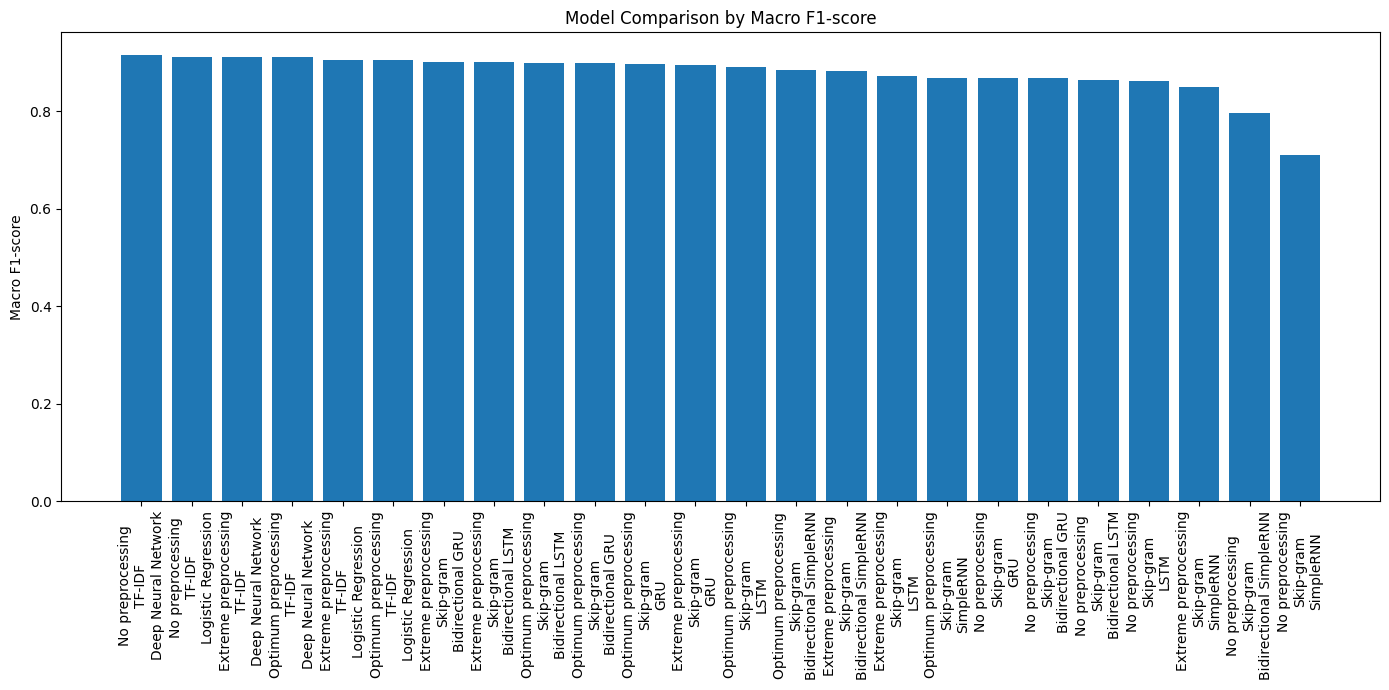

In [ ]:
# 39 Plot model comparison by Macro F1-score

plt.figure(figsize=(14, 7))

experiment_labels = (
    result_df["Preprocessing"] + "\n" +
    result_df["Representation"] + "\n" +
    result_df["Model"]
)

plt.bar(range(len(result_df)), result_df["Macro F1"])
plt.xticks(range(len(result_df)), experiment_labels, rotation=90)
plt.ylabel("Macro F1-score")
plt.title("Model Comparison by Macro F1-score")
plt.tight_layout()
plt.show()


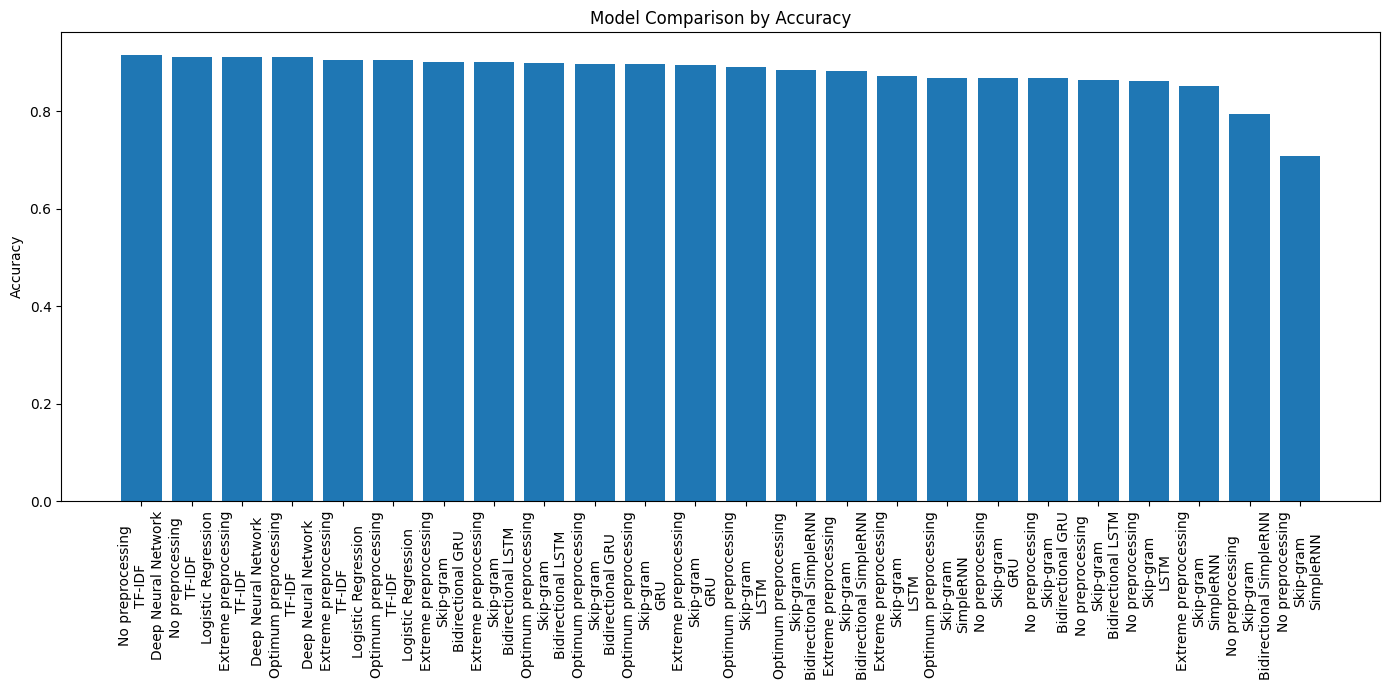

In [ ]:
#40 Plot model comparison by Accuracy

plt.figure(figsize=(14, 7))

plt.bar(range(len(result_df)), result_df["Accuracy"])
plt.xticks(range(len(result_df)), experiment_labels, rotation=90)
plt.ylabel("Accuracy")
plt.title("Model Comparison by Accuracy")
plt.tight_layout()
plt.show()


,Accuracy,Macro F1
Preprocessing,,
Extreme preprocessing,0.890385,0.890132
No preprocessing,0.849396,0.850272
Optimum preprocessing,0.894313,0.894281


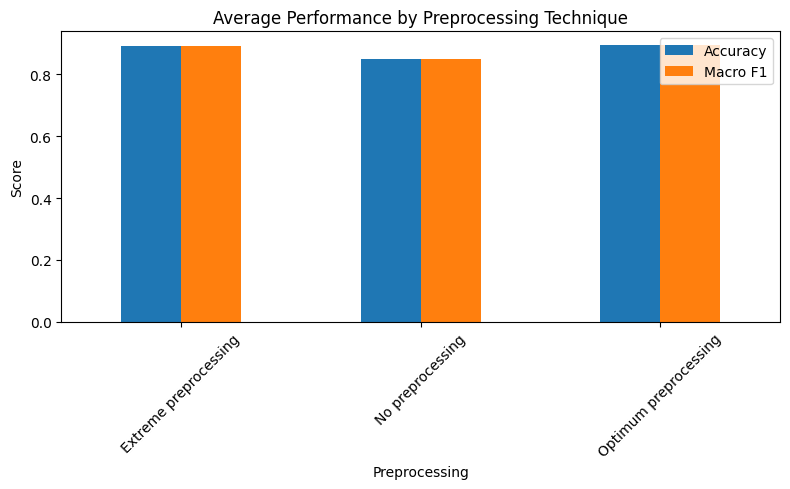

In [ ]:
#41 Average performance by preprocessing technique

preprocessing_summary = result_df.groupby("Preprocessing")[["Accuracy", "Macro F1"]].mean()

display(preprocessing_summary)

preprocessing_summary.plot(kind="bar", figsize=(8, 5))
plt.title("Average Performance by Preprocessing Technique")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,Accuracy,Macro F1
Model,,
Deep Neural Network,0.912917,0.912794
Logistic Regression,0.908000,0.907770
Bidirectional GRU,0.889278,0.889295
Bidirectional LSTM,0.888028,0.887976
GRU,0.887250,0.887216
LSTM,0.875722,0.875451
Bidirectional SimpleRNN,0.853889,0.855083
SimpleRNN,0.809167,0.810242


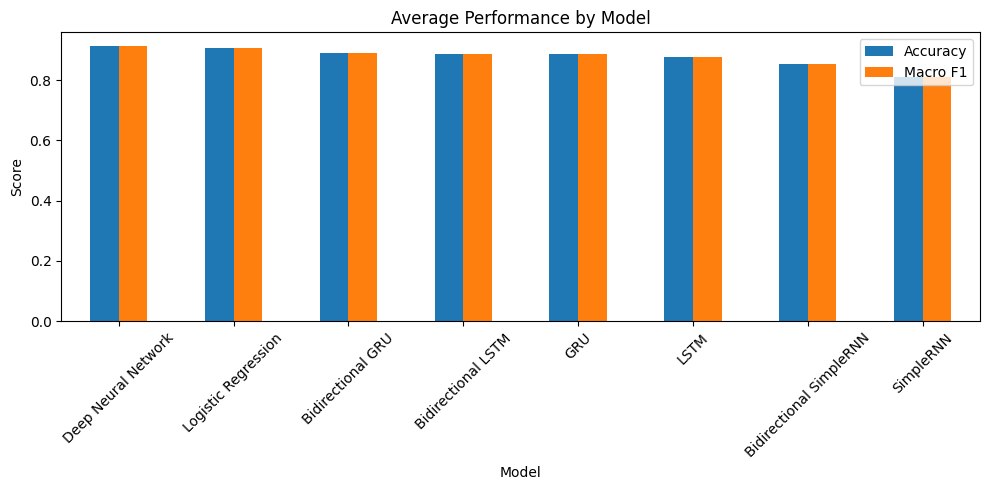

In [ ]:
#42 Average performance by model

model_summary = result_df.groupby("Model")[["Accuracy", "Macro F1"]].mean()
model_summary = model_summary.sort_values(by="Macro F1", ascending=False)

display(model_summary)

model_summary.plot(kind="bar", figsize=(10, 5))
plt.title("Average Performance by Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 16. Find Best and Worst Model

In [ ]:
#43 Identify best and worst experiments

best_result = result_df.iloc[0]
worst_result = result_df.iloc[-1]

print("Best Performing Experiment:")
display(pd.DataFrame([best_result]))

print("\nWorst Performing Experiment:")
display(pd.DataFrame([worst_result]))


Best Performing Experiment:


,Preprocessing,Representation,Model,Accuracy,Macro F1
0,No preprocessing,TF-IDF,Deep Neural Network,0.9165,0.916302



Worst Performing Experiment:


,Preprocessing,Representation,Model,Accuracy,Macro F1
23,No preprocessing,Skip-gram,SimpleRNN,0.707583,0.711194


Total confusion matrices available: 24
Total final experiments in result table: 24


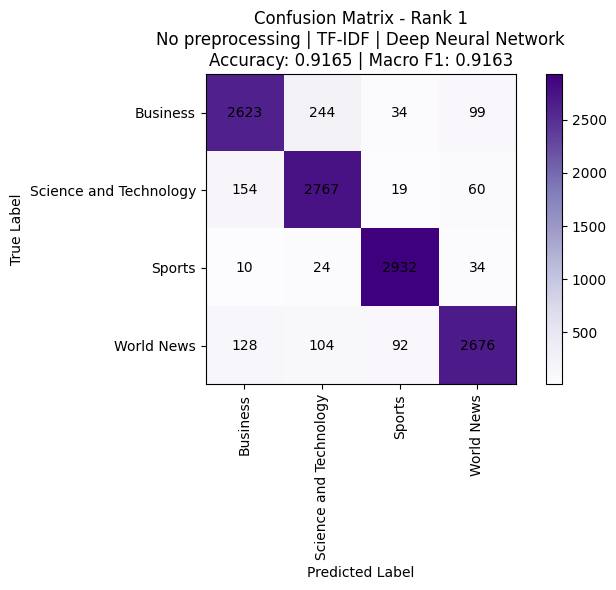

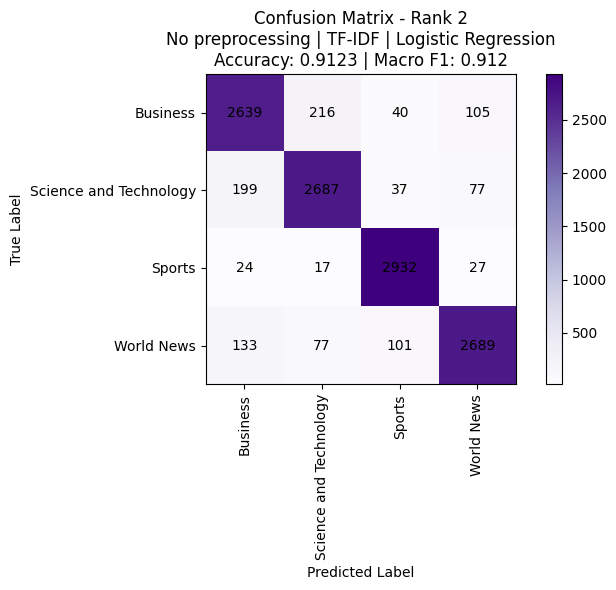

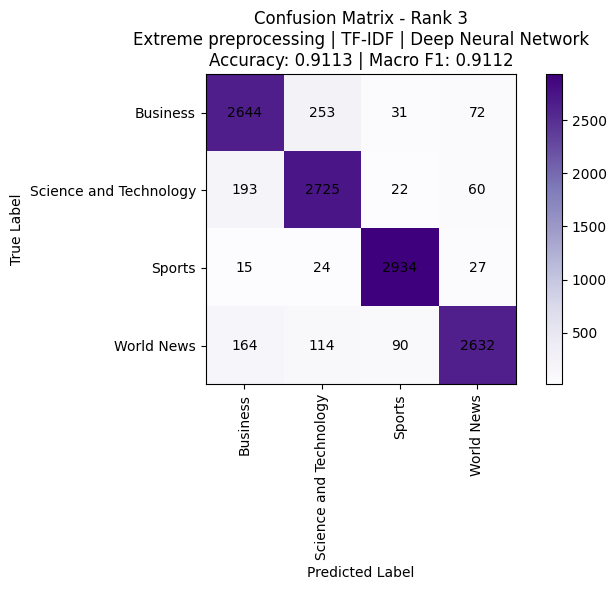

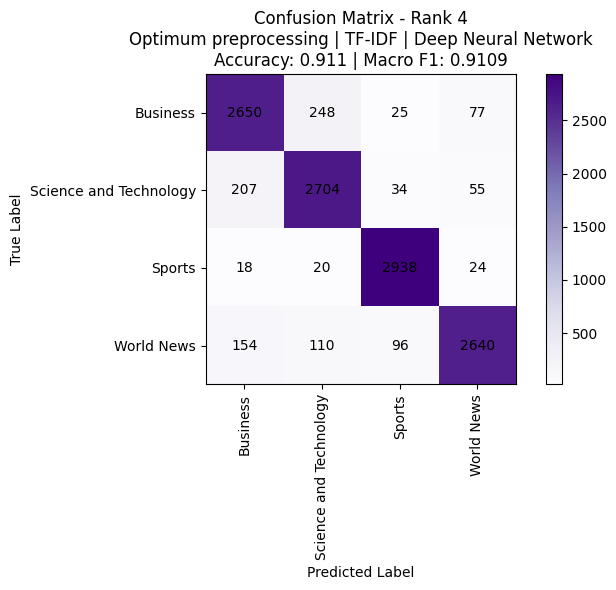

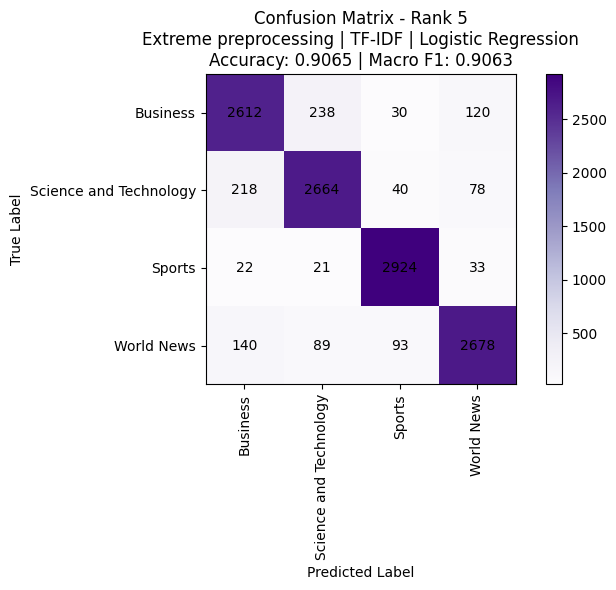

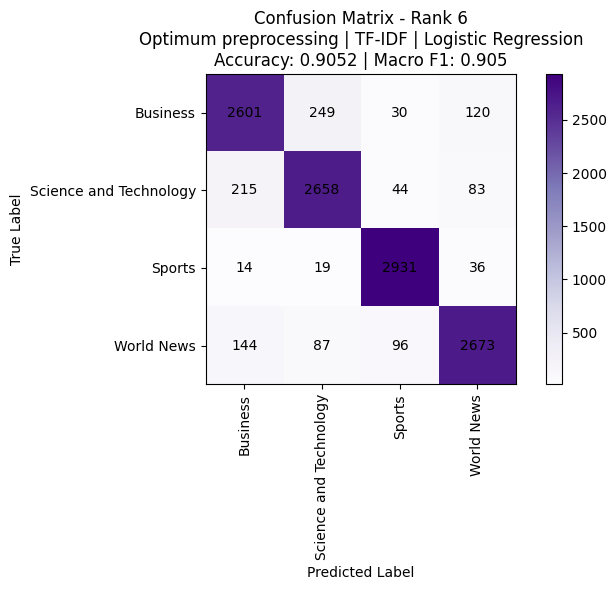

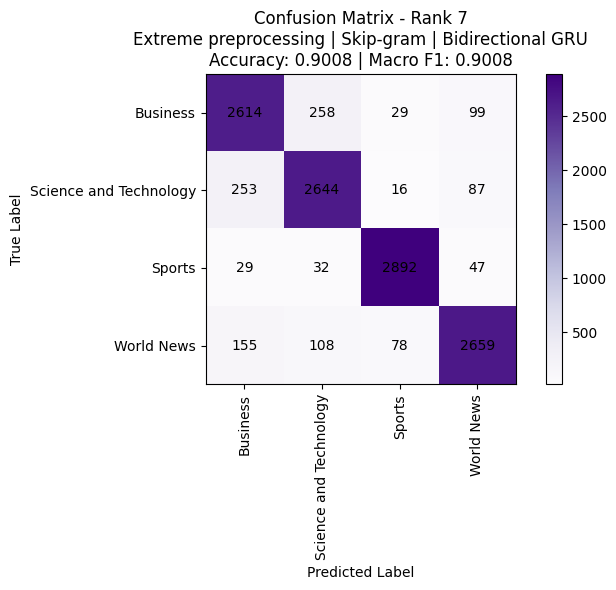

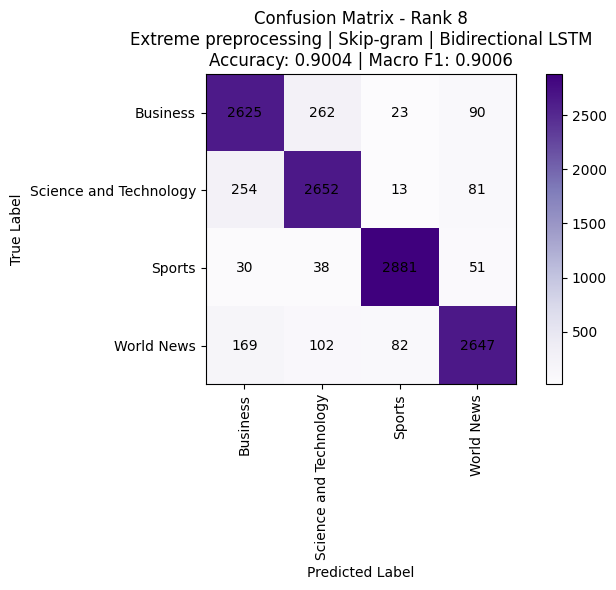

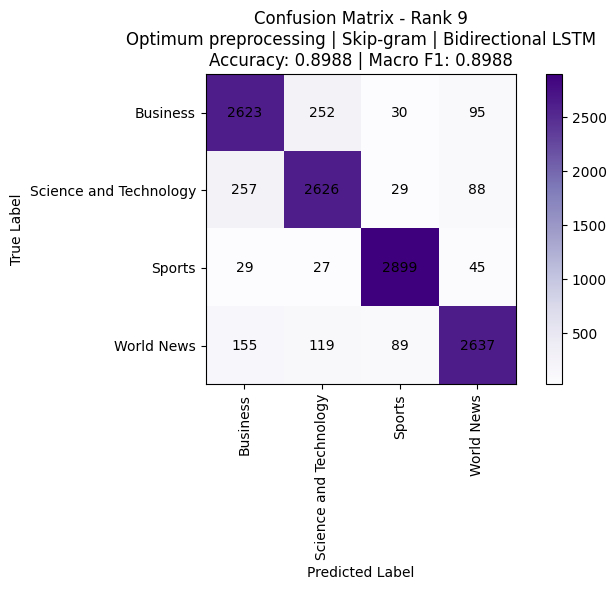

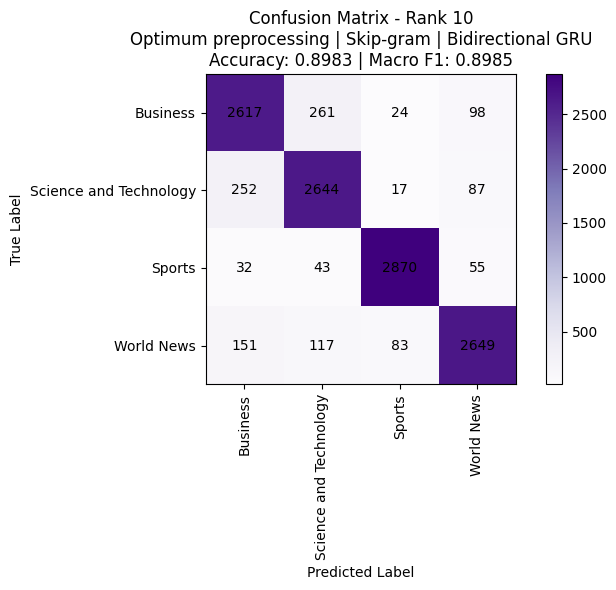

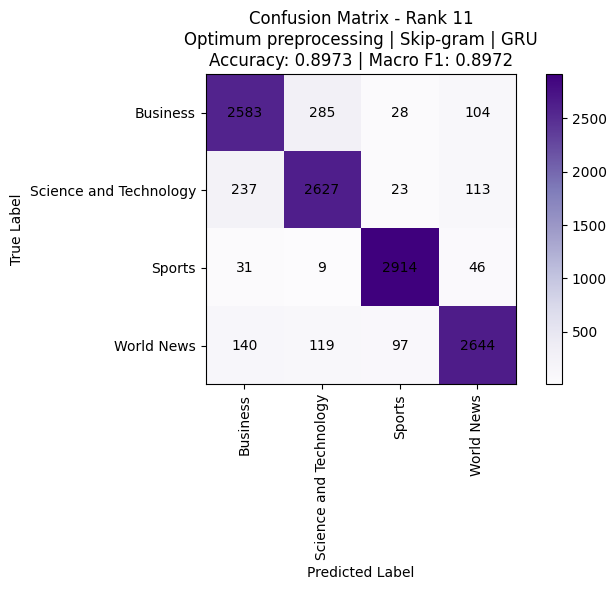

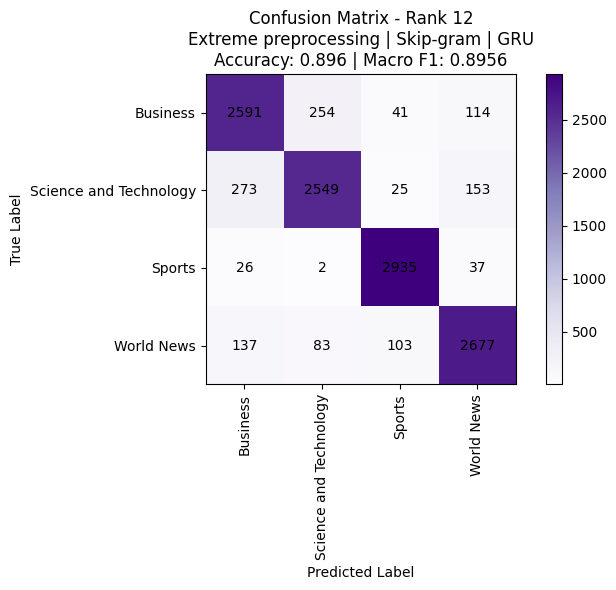

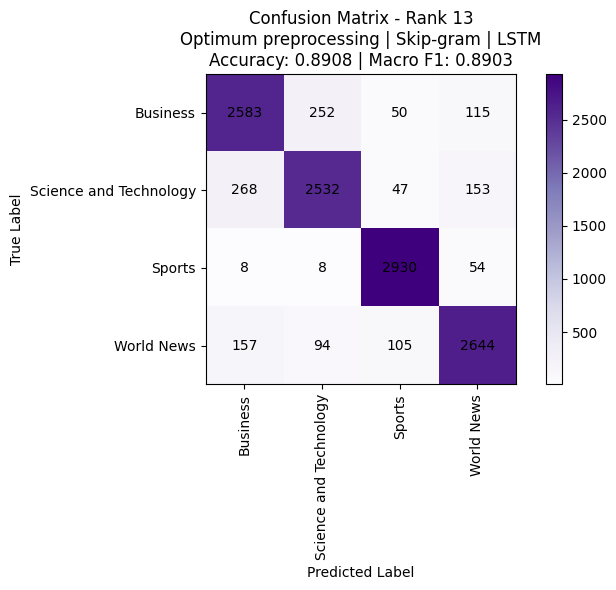

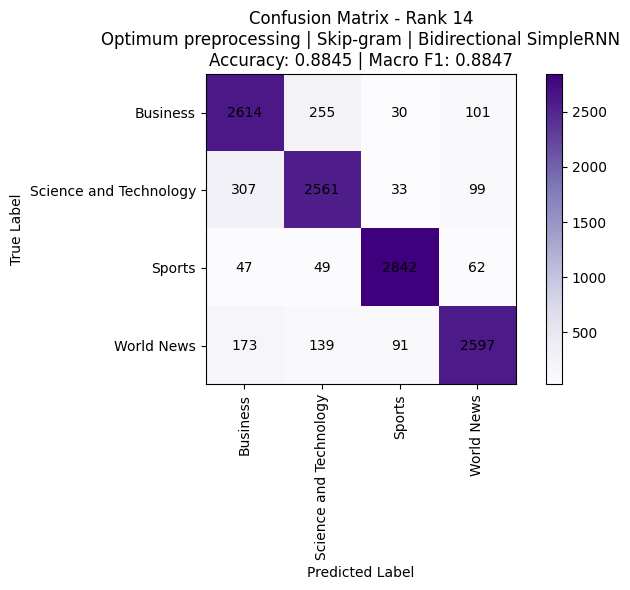

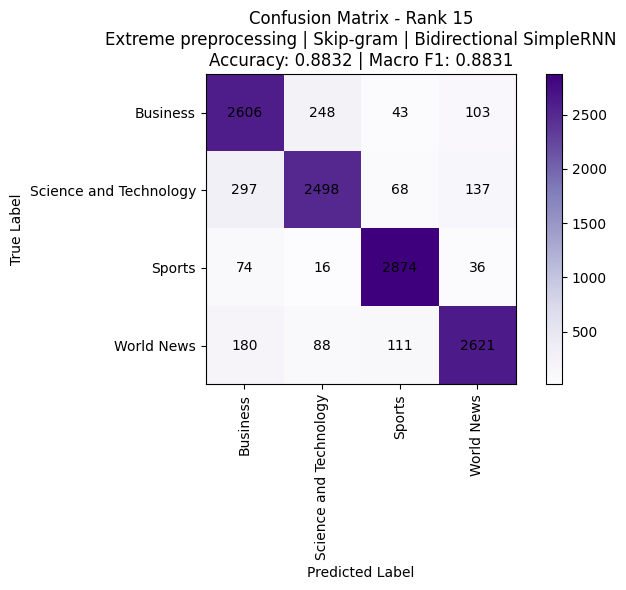

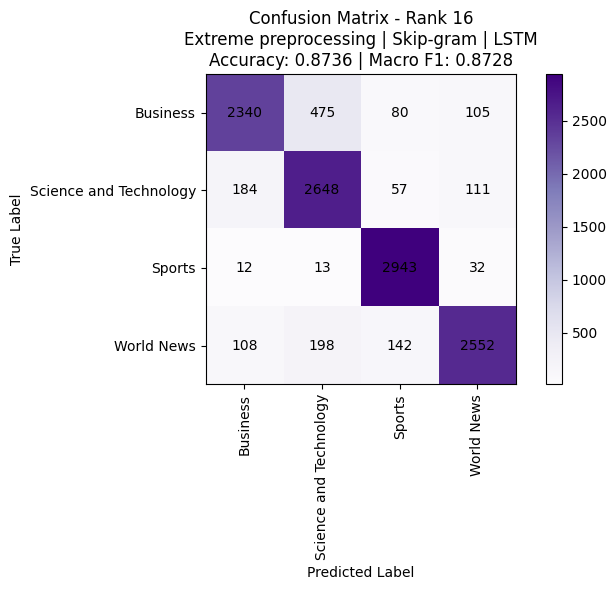

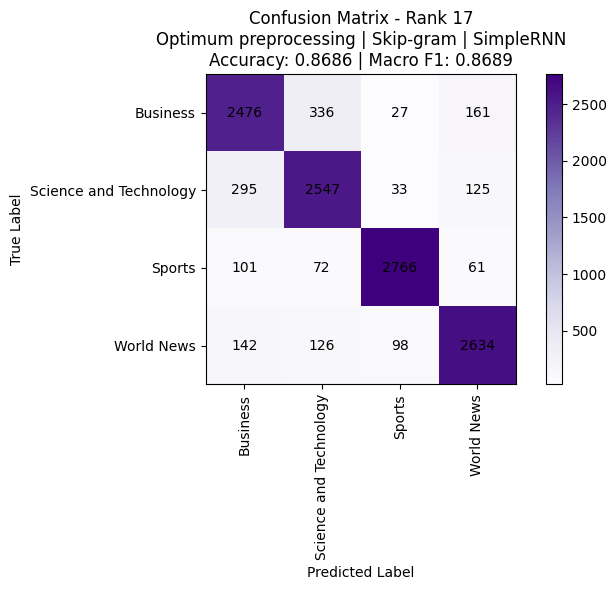

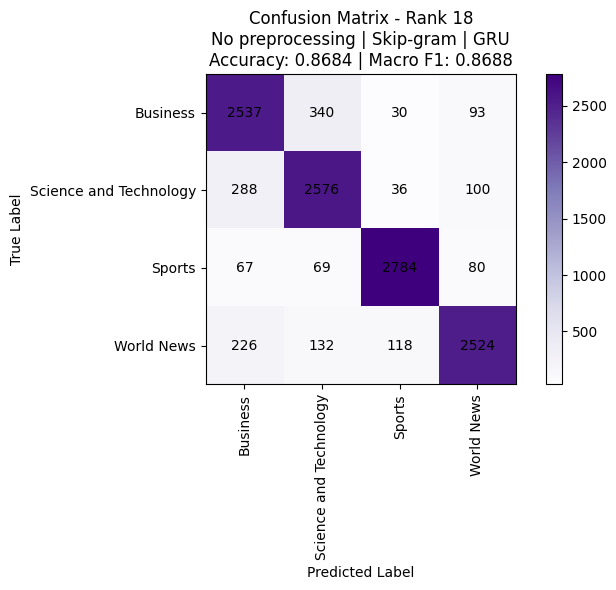

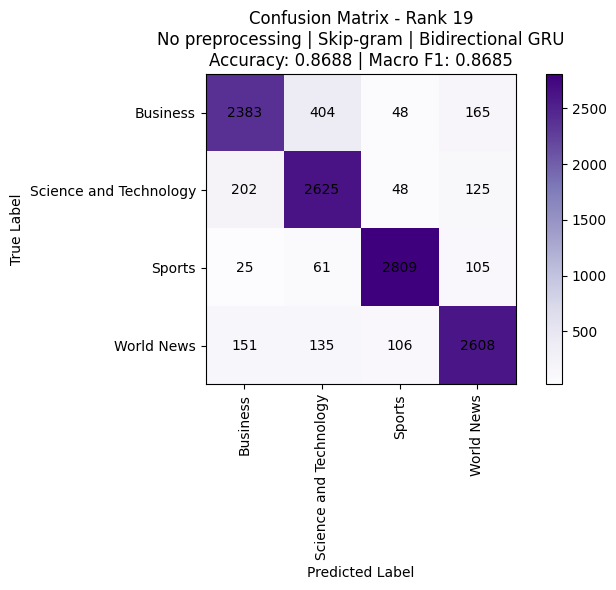

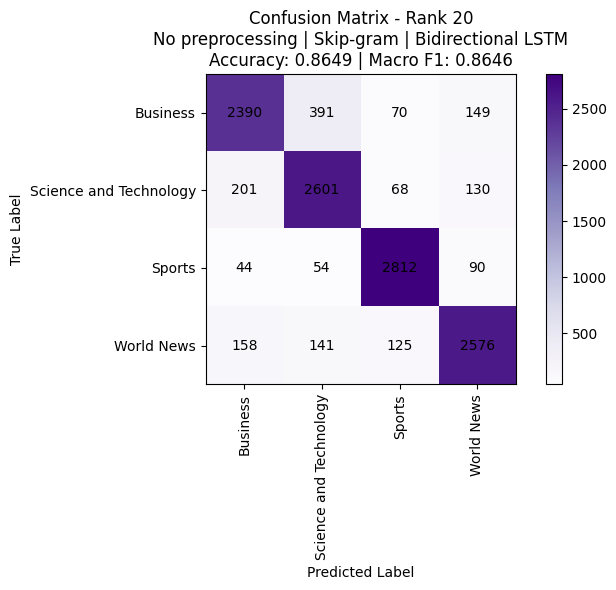

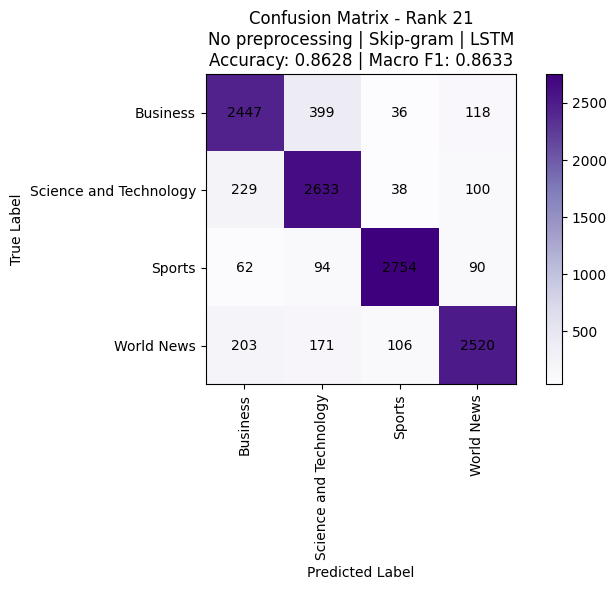

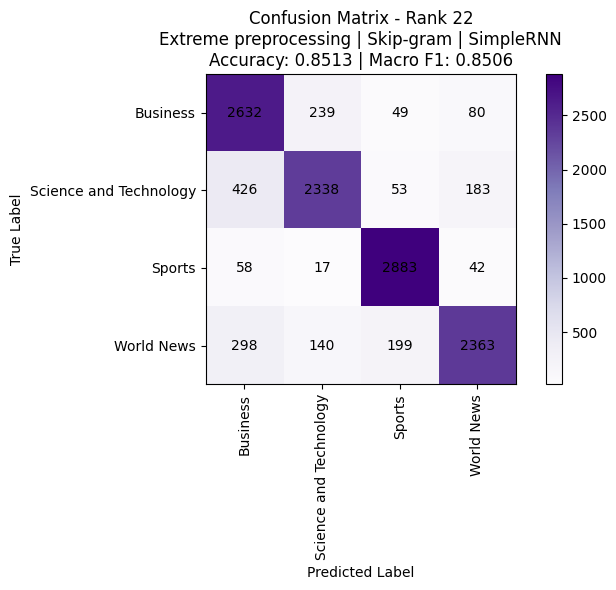

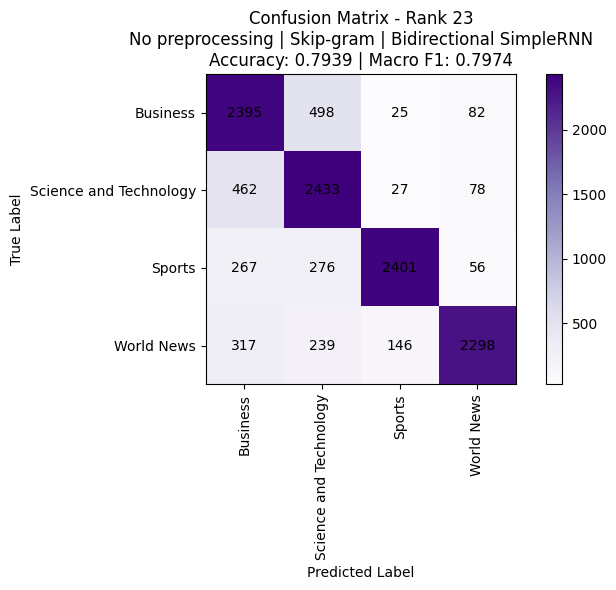

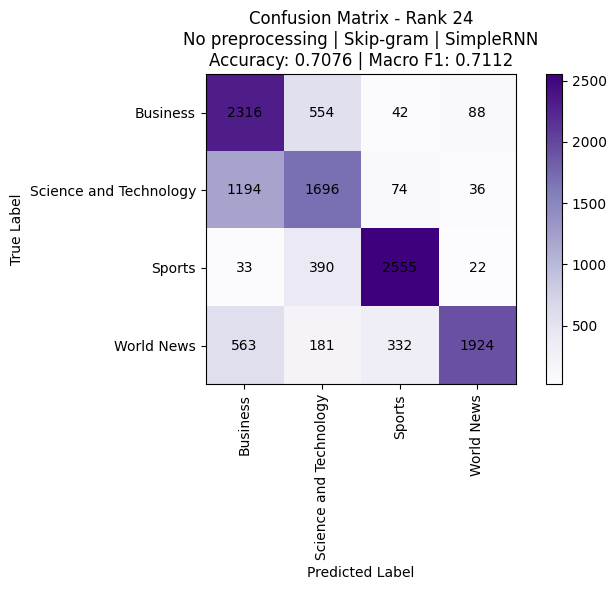

All confusion matrices displayed and saved in: all_confusion_matrices


In [ ]:
#44 Plot confusion matrices for all models

import os
import re

confusion_matrix_folder = "all_confusion_matrices"
os.makedirs(confusion_matrix_folder, exist_ok=True)

def safe_filename(text):
    text = re.sub(r"[^a-zA-Z0-9]+", "_", text)
    text = text.strip("_")
    return text[:120]

def plot_confusion_matrix(cm, title, filename=None):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Purples")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(range(num_classes), class_names, rotation=90)
    plt.yticks(range(num_classes), class_names)
    plt.colorbar()

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

sorted_results_for_cm = result_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

print("Total confusion matrices available:", len(all_confusion_matrices))
print("Total final experiments in result table:", len(sorted_results_for_cm))

for index, row in sorted_results_for_cm.iterrows():
    experiment_key = (
        row["Preprocessing"] + " | " +
        row["Representation"] + " | " +
        row["Model"]
    )

    if experiment_key not in all_confusion_matrices:
        print("Missing confusion matrix for:", experiment_key)
        continue

    rank = index + 1

    title = (
        "Confusion Matrix - Rank " + str(rank) + "\n" +
        row["Preprocessing"] + " | " +
        row["Representation"] + " | " +
        row["Model"] + "\n" +
        "Accuracy: " + str(round(row["Accuracy"], 4)) +
        " | Macro F1: " + str(round(row["Macro F1"], 4))
    )

    filename = os.path.join(
        confusion_matrix_folder,
        str(rank).zfill(2) + "_" + safe_filename(experiment_key) + ".png"
    )

    plot_confusion_matrix(
        all_confusion_matrices[experiment_key],
        title,
        filename
    )

print("All confusion matrices displayed and saved in:", confusion_matrix_folder)

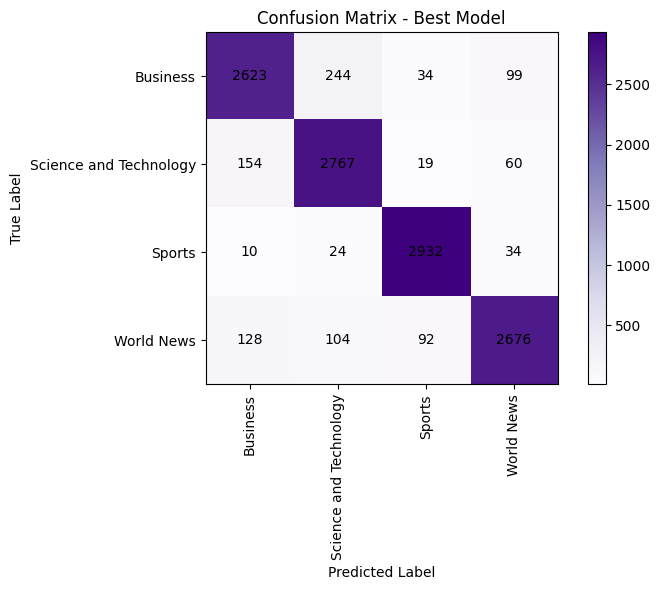

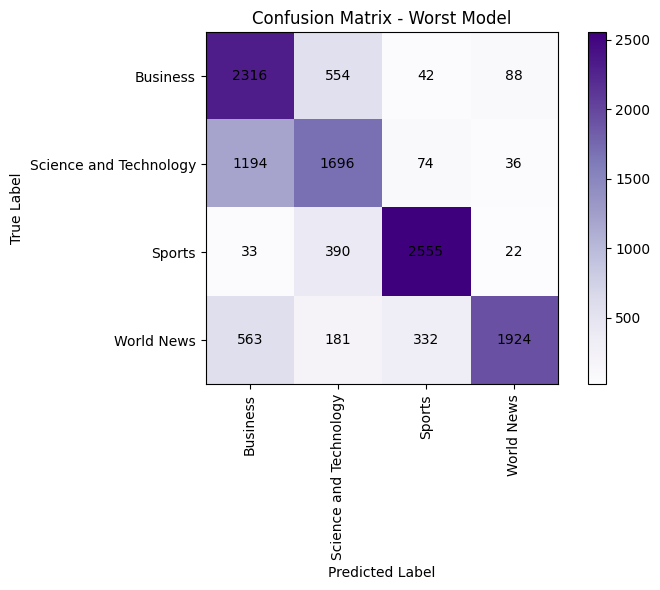

In [ ]:
#44 Plot confusion matrix for best and worst models

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Purples")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(range(num_classes), class_names, rotation=90)
    plt.yticks(range(num_classes), class_names)
    plt.colorbar()

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

best_key = (
    best_result["Preprocessing"] + " | " +
    best_result["Representation"] + " | " +
    best_result["Model"]
)

worst_key = (
    worst_result["Preprocessing"] + " | " +
    worst_result["Representation"] + " | " +
    worst_result["Model"]
)

plot_confusion_matrix(
    all_confusion_matrices[best_key],
    "Confusion Matrix - Best Model"
)

plot_confusion_matrix(
    all_confusion_matrices[worst_key],
    "Confusion Matrix - Worst Model"
)


In [ ]:
#45 Notes for report discussion

hyperparameter_notes = pd.DataFrame([
    {
        "Part": "Preprocessing",
        "Decision": "Three versions were used: raw text, extreme preprocessing, and EDA-based optimum preprocessing.",
        "Reason": "EDA showed repeated wrapper text and noisy tokens such as lt, gt, http, https, www, quot, quote, reuters, ap, afp, profile, and research. The clean versions remove these noisy tokens, while raw text is kept unchanged for comparison."
    },
    {
        "Part": "Optimum preprocessing",
        "Decision": "Dataset noise, source tokens, stopwords, and very short useless words were removed. Lemmatization and stemming were not used in optimum preprocessing.",
        "Reason": "The EDA showed that this news topic classification task depends strongly on keywords. This version reduces noisy vocabulary while keeping original keyword forms readable."
    },
    {
        "Part": "POS tagging and parsing",
        "Decision": "POS tagging and chunk parsing were inspected only for understanding the text structure, not as final preprocessing features.",
        "Reason": "The project specifically requires TF-IDF and Skip-gram representations. Adding POS/parsing features would make the pipeline more complex and was not needed for the required experiments."
    },
    {
        "Part": "No preprocessing vs optimum preprocessing",
        "Decision": "Similar accuracy is expected in some models.",
        "Reason": "TF-IDF tokenization already ignores much punctuation, and repeated wrapper words appear in almost every document so they get low importance. The main topic words remain present in both raw and optimum text."
    },
    {
        "Part": "TF-IDF",
        "Decision": "Different max_features and ngram_range values were tested.",
        "Reason": "Unigrams are simple, while unigram-bigram features can capture short phrase information from news headlines."
    },
    {
        "Part": "ML model",
        "Decision": "Logistic Regression was selected.",
        "Reason": "It is strong for TF-IDF text classification and easy to explain."
    },
    {
        "Part": "Class weights",
        "Decision": "Balanced class weights were used for Logistic Regression and neural network training.",
        "Reason": "The training class distribution is not perfectly balanced, so class weights help reduce bias toward larger classes."
    },
    {
        "Part": "DNN",
        "Decision": "DNN settings used 15 epochs with early stopping and different dropout/max_features values.",
        "Reason": "The project requires at least 3 to 4 layers and 128+ neurons in the first layer. Validation macro F1 is used to choose the best setting."
    },
    {
        "Part": "Skip-gram",
        "Decision": "Word2Vec was trained using sg=1 with 15 epochs on the training text.",
        "Reason": "The project requires Skip-gram for the recurrent neural network models."
    },
    {
        "Part": "RNN models",
        "Decision": "SimpleRNN, GRU, LSTM, and their bidirectional versions were tuned using 15 epochs and two different unit/dropout settings.",
        "Reason": "These are all required by the project specification, and validation macro F1 is used to select the better setting before final test evaluation."
    }
])

display(hyperparameter_notes)


,Part,Decision,Reason
0,Preprocessing,"Three versions were used: raw text, extreme pr...",EDA showed repeated wrapper text and noisy tok...
1,Optimum preprocessing,"Dataset noise, source tokens, stopwords, and v...",The EDA showed that this news topic classifica...
2,POS tagging and parsing,POS tagging and chunk parsing were inspected o...,The project specifically requires TF-IDF and S...
3,No preprocessing vs optimum preprocessing,Similar accuracy is expected in some models.,TF-IDF tokenization already ignores much punct...
4,TF-IDF,Different max_features and ngram_range values ...,"Unigrams are simple, while unigram-bigram feat..."
5,ML model,Logistic Regression was selected.,It is strong for TF-IDF text classification an...
6,Class weights,Balanced class weights were used for Logistic ...,The training class distribution is not perfect...
7,DNN,DNN settings used 15 epochs with early stoppin...,The project requires at least 3 to 4 layers an...
8,Skip-gram,Word2Vec was trained using sg=1 with 15 epochs...,The project requires Skip-gram for the recurre...
9,RNN models,"SimpleRNN, GRU, LSTM, and their bidirectional ...",These are all required by the project specific...


## 17. Save Final Results

In [ ]:
#46 Save final results

result_df.to_csv("final_model_results.csv", index=False)
ml_tuning_df.to_csv("ml_tuning_log.csv", index=False)
dnn_tuning_df.to_csv("dnn_tuning_log.csv", index=False)
sequence_tuning_df.to_csv("sequence_model_validation_log.csv", index=False)
hyperparameter_notes.to_csv("hyperparameter_decision_notes.csv", index=False)

with open("classification_reports.json", "w") as file:
    json.dump(all_reports, file, indent=4)

confusion_matrices_json = {
    key: value.tolist()
    for key, value in all_confusion_matrices.items()
}

with open("confusion_matrices.json", "w") as file:
    json.dump(confusion_matrices_json, file, indent=4)

print("Saved files:")
print("final_model_results.csv")
print("ml_tuning_log.csv")
print("dnn_tuning_log.csv")
print("sequence_model_validation_log.csv")
print("hyperparameter_decision_notes.csv")
print("classification_reports.json")
print("confusion_matrices.json")


Saved files:
final_model_results.csv
ml_tuning_log.csv
dnn_tuning_log.csv
sequence_model_validation_log.csv
hyperparameter_decision_notes.csv
classification_reports.json
confusion_matrices.json


In [ ]:
#47 Download saved result files in Google Colab

try:
    from google.colab import files

    files.download("final_model_results.csv")
    files.download("ml_tuning_log.csv")
    files.download("dnn_tuning_log.csv")
    files.download("sequence_model_validation_log.csv")
    files.download("hyperparameter_decision_notes.csv")
    files.download("classification_reports.json")
    files.download("confusion_matrices.json")

except:
    print("Download option is available only in Google Colab.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Checklist

This corrected notebook contains the required project parts:

- EDA section
- preprocessing functions
- raw, extreme, and optimum datasets
- duplicate training rows removed before validation split
- EDA-based explanation for optimum preprocessing
- POS tagging and shallow parsing check for analysis only
- explanation for similar raw vs optimum performance
- TF-IDF feature extraction
- Logistic Regression machine learning model
- Deep Neural Network using TF-IDF
- Skip-gram Word2Vec
- padded sequences and embedding matrix
- SimpleRNN
- GRU
- LSTM
- Bidirectional SimpleRNN
- Bidirectional GRU
- Bidirectional LSTM
- manual tuning logs using validation Macro F1
- balanced class weights for ML and neural models
- 15 epochs for DNN and sequence models, with early stopping
- accuracy, macro F1-score, confusion matrix, and classification report
- final result dataframe
- comparison plots
- best and worst model
- saved result files
